# 🛰️ End-to-End DL Project — Satellite Land-Use Classifier

> **What you'll build:** a real image-classification product on EuroSAT satellite tiles: clean splits, a from-scratch baseline, ResNet-18 transfer learning with early stopping, calibrated confidence with a "send to a human" rule, Grad-CAM error analysis, `torch.export`, measured CPU/GPU latency, and a tested FastAPI upload service in a CPU-only Docker image with CI.

| | |
|---|---|
| **Difficulty** | 🟡 Intermediate → 🔴 Advanced |
| **Time** | ~5 hours to read and run (the notebook itself runs in about 4–5 minutes on an Apple Silicon laptop, plus downloads and the first Docker build), +3 hours for stretch goals |
| **Prerequisites** | [PyTorch](../04_Deep_Learning/02_PyTorch.ipynb) · [CNNs and Transfer Learning](../06_Computer_Vision/02_CNNs_and_Transfer_Learning.ipynb) (helpful: [FastAPI](../10_Model_Serving/01_FastAPI.ipynb), [Docker and CI/CD](../10_Model_Serving/02_Docker_and_CI_CD.ipynb), [End-to-End ML Project](01_End_to_End_ML_Project.ipynb)) |
| **Tested with** | Python 3.12 · torch 2.14 (MPS) · torchvision 0.29 · scikit-learn 1.9 · FastAPI 0.141 · pytest 9 · Docker 28 |
| **Interview relevance** | ⭐⭐⭐ High — "walk me through a DL project", transfer learning choices, calibration, error analysis, export and latency, serving images safely |

**The project folder:** everything runs from [`image_classifier/`](image_classifier/README.md) next to this notebook — a repository you could push to GitHub. The notebook imports that package instead of copying its code.

## 🤔 Problem & Business Goal

An environmental-monitoring team receives thousands of satellite image tiles every week. Analysts label each tile's **land use** (forest, river, highway, residential, crops, …) to track deforestation and urban growth. Labelling by hand is slow, so they want a model that:

1. labels tiles automatically when it is confident, and
2. **sends uncertain tiles to a human** instead of guessing.

**Dataset:** [EuroSAT](https://github.com/phelber/EuroSAT) (RGB version, MIT license) — 27,000 labelled 64×64-pixel tiles from the European Sentinel-2 satellite (each pixel is 10 m × 10 m on the ground), 10 classes with 2,000–3,000 tiles each.

**Success criteria, written down before training:**

| # | Criterion | Why |
|---|---|---|
| 1 | test **macro-F1 ≥ 0.95** | macro-F1 averages the F1 score of every class equally, so small classes count as much as big ones |
| 2 | every class **recall ≥ 0.90** | no land-use type may be systematically missed |
| 3 | calibrated **ECE ≤ 0.03** | confidence must be trustworthy for the "send to a human" rule |
| 4 | **CPU p95 latency ≤ 50 ms** per image (preprocessing + model) | one CPU container can serve the tool without a GPU |
| 5 | training in **~10 minutes** on a laptop GPU | cheap to retrain and iterate |

**Key terms.** *Transfer learning*: start from a network pretrained on a large dataset (ImageNet) and adapt it. *Recall* for a class: the share of its tiles we label correctly. *ECE* (expected calibration error): the average gap between confidence and accuracy. *p95 latency*: 95% of requests are faster than this.

## 🗺️ Architecture

```mermaid
flowchart LR
    A["EuroSAT RGB zip (torchvision download)"] --> B["data.py: stratified split → CSV + quality subset"]
    B --> C["load once: uint8 tensors (N, 3, 64, 64)"]
    C --> D["train.py: SmallCNN baseline vs ResNet-18 transfer (augmentation, one-cycle LR, early stopping)"]
    D -->|validation| E["evaluate.py: temperature scaling + review threshold"]
    E --> F["export.py: torch.export → model.pt2 + metadata.json"]
    F -->|"test (once)"| G["metrics with CIs, confusions, Grad-CAM"]
    F --> H["api.py: FastAPI /predict (upload, top-k, needs_review)"]
    H --> I["CPU-only Docker image"]
    J["tests/ + CI (quality gate on 200 fixed test tiles)"] --> I
```

| Module | Role |
|---|---|
| `config.py` · `data.py` · `transforms.py` | classes, paths, limits · download + splits · **one** decode/preprocess path + augmentation |
| `models.py` · `train.py` | baseline CNN and ResNet-18 (normalization inside the model) · training loop + CLI |
| `evaluate.py` · `gradcam.py` | CIs, per-class metrics, calibration, review threshold · Grad-CAM |
| `export.py` · `predict.py` · `api.py` | `torch.export` + latency · inference from the `.pt2` file only · upload service |

Design choice: **normalization and resizing live inside the model**, and the API reuses the exact decoding function used for training. The exported file therefore takes plain `[0, 1]` RGB tiles, and there is no second copy of preprocessing to drift out of sync (*training/serving skew*).

## ⚙️ Setup

Run the cell below first. If a package is missing, uncomment the `%pip` line, run it once, and restart the kernel.

- **No installation of the project:** `image_classifier/src` is added to `sys.path`.
- **Hardware:** Apple GPU (**MPS**) → CUDA → CPU. Timings in this notebook come from an Apple Silicon laptop; on a CPU-only machine training is several times slower (lower the epochs in Steps 4–5).
- **Downloads (once):** EuroSAT RGB (94 MB) into `image_classifier/data/` (git-ignored); ResNet-18 ImageNet weights (45 MB) into PyTorch's cache; for Docker, CPU PyTorch wheels (~200 MB) inside the image build.
- **Memory:** all 27,000 tiles as `uint8` take ~330 MB; training ResNet-18 at batch 128 uses ~1.5 GB of GPU memory.
- **Files written:** `image_classifier/data/`, `image_classifier/artifacts/` (git-ignored, recreated by training), scratch files in `_outputs/image_classifier/`.
- `run()` prints a command and its output like a terminal. `check()` gives exercise feedback: **✅** correct, **⏳** not attempted yet, **❌** wrong (with a hint).

In [1]:
# %pip install -q "torch>=2.14,<3" "torchvision>=0.29,<1" "scikit-learn>=1.9,<2" "pandas>=3.0,<4" "fastapi>=0.141,<1" "uvicorn>=0.52,<1" "python-multipart>=0.0.20" "httpx>=0.28" "pytest>=9" pillow matplotlib pyyaml

import copy
import gc
import importlib.metadata as md
import importlib.util
import inspect
import json
import math
import os
import re
import shutil
import signal
import socket
import subprocess
import sys
import time
from pathlib import Path

import httpx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import yaml
from sklearn.metrics import ConfusionMatrixDisplay
from torch.optim.lr_scheduler import OneCycleLR

NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR = NOTEBOOK_DIR / "image_classifier"
OUTPUT_DIR = NOTEBOOK_DIR / "_outputs" / "image_classifier"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(PROJECT_DIR / "src"))               # import the project package without installing it

from image_classifier import config as cfg  # noqa: E402
from image_classifier.data import download_eurosat, list_samples, load_images, prepare_data  # noqa: E402
from image_classifier.evaluate import (choose_review_threshold, coverage_table, expected_calibration_error, fit_temperature,  # noqa: E402
                                       per_class_table, summarize_test, top_confusions)
from image_classifier.export import export_model, measure_latency, save_bundle  # noqa: E402
from image_classifier.gradcam import GradCAM  # noqa: E402
from image_classifier.models import SmallCNN, TransferResNet, count_parameters  # noqa: E402
from image_classifier.predict import ImageClassifier  # noqa: E402
from image_classifier.train import REVIEW_TARGET_ACCURACY, TrainConfig, build_metadata, fit, param_groups, pick_device, predict_logits  # noqa: E402
from image_classifier.transforms import augment_batch, decode_image_bytes, to_uint8_tensor  # noqa: E402

for pkg in ["torch", "torchvision", "scikit-learn", "fastapi", "pydantic", "pytest"]:
    print(f"{pkg} {md.version(pkg)}", end=" | ")
print(f"Python {sys.version.split()[0]}")

torch.manual_seed(cfg.SEED)
DEVICE = pick_device()
CPU = torch.device("cpu")
DOCKER, UV = shutil.which("docker"), shutil.which("uv")
print("device:", DEVICE, "| docker:", "found" if DOCKER else "not installed", "| uv:", "found" if UV else "not installed")
if DEVICE.type == "cpu":
    print("⚠️ No GPU found: training will be slow — lower the epochs in Steps 4 and 5.")


def rel(text):
    """Paths relative to this notebook; never print the local home folder."""
    text = str(text).replace(str(NOTEBOOK_DIR) + os.sep, "").replace(str(NOTEBOOK_DIR), ".")
    return text.replace(str(Path.home()), "~")


def run(cmd, cwd=PROJECT_DIR, env=None, max_lines=30, timeout=1200):
    """Run a command like a terminal: `$ command`, the last `max_lines` of output, exit code and time."""
    names = {sys.executable: "python", DOCKER: "docker", UV: "uv"}
    print("$", rel(" ".join(names.get(str(c), str(c)) for c in cmd)))
    start = time.perf_counter()
    result = subprocess.run([str(c) for c in cmd], cwd=cwd, env={**os.environ, **(env or {})}, stdout=subprocess.PIPE,
                            stderr=subprocess.STDOUT, text=True, timeout=timeout)
    lines = re.sub(r"\x1b\[[0-9;]*m", "", result.stdout).rstrip().splitlines()
    if len(lines) > max_lines:
        print(f"  … ({len(lines) - max_lines} earlier lines hidden)")
        lines = lines[-max_lines:]
    for line in lines:
        print("  " + rel(line))
    result.seconds = time.perf_counter() - start
    print(f"  [exit code {result.returncode} · {result.seconds:.1f} s]")
    return result


def show_source(obj, max_lines=60, start_at=None):
    """Print real source code from the project package (optionally from the first line containing `start_at`)."""
    lines = inspect.getsource(obj).splitlines()
    if start_at is not None:
        lines = lines[next(i for i, line in enumerate(lines) if start_at in line):]
    print(f"# {rel(inspect.getsourcefile(obj))}")
    print("\n".join(lines[:max_lines]) + (f"\n# … {len(lines) - max_lines} more lines" if len(lines) > max_lines else ""))


def free_port():
    with socket.socket() as s:
        s.bind(("127.0.0.1", 0))
        return s.getsockname()[1]


def free_memory():
    gc.collect()
    if DEVICE.type == "mps":
        torch.mps.empty_cache()
    elif DEVICE.type == "cuda":
        torch.cuda.empty_cache()


class UvicornServer:
    """`python -m uvicorn target` in a background process on a free port; stopped with SIGTERM on exit."""

    def __init__(self, target, cwd, env=None, ready_path="/ready"):
        self.target, self.cwd, self.ready_path = target, cwd, ready_path
        self.port = free_port()
        self.base_url = f"http://127.0.0.1:{self.port}"
        self.env = {**os.environ, "PYTHONUNBUFFERED": "1", **(env or {})}
        self.log_path = OUTPUT_DIR / f"uvicorn_{self.port}.log"

    def __enter__(self):
        self._log = open(self.log_path, "w")
        self.proc = subprocess.Popen([sys.executable, "-m", "uvicorn", self.target, "--host", "127.0.0.1", "--port", str(self.port)],
                                     cwd=self.cwd, env=self.env, stdout=self._log, stderr=subprocess.STDOUT)
        start = time.perf_counter()
        while time.perf_counter() - start < 120:
            if self.proc.poll() is not None:
                raise RuntimeError(f"uvicorn exited early:\n{rel(self.log_path.read_text())[-2000:]}")
            try:
                if httpx.get(self.base_url + self.ready_path, timeout=1).status_code == 200:
                    self.startup_seconds = time.perf_counter() - start
                    return self
            except httpx.TransportError:
                pass
            time.sleep(0.2)
        self.__exit__()
        raise TimeoutError("server not ready after 120 s")

    def __exit__(self, *exc):
        if self.proc.poll() is None:
            self.proc.send_signal(signal.SIGTERM)
            try:
                self.proc.wait(timeout=20)
            except subprocess.TimeoutExpired:
                self.proc.kill()
        self._log.close()

    def log_text(self):
        return rel(self.log_path.read_text())


def check(name, got, expected, hint="", rel_tol=1e-6):
    """✅ if correct, ⏳ if not attempted yet (None), ❌ AssertionError with a hint otherwise."""
    if got is None or got is ...:
        print(f"⏳ {name}: not attempted yet — replace None with your answer.")
        return
    if isinstance(expected, (int, float, np.number)) and not isinstance(expected, bool):
        ok = isinstance(got, (int, float, np.number)) and math.isclose(float(got), float(expected), rel_tol=rel_tol, abs_tol=1e-9)
    else:
        ok = got == expected
    assert ok, f"❌ {name}: not quite (got {got!r}). {hint}"
    print(f"✅ {name}: correct!")


def show_tile(ax, image_uint8, title="", fontsize=8):
    ax.imshow(image_uint8.permute(1, 2, 0).numpy())
    ax.set_title(title, fontsize=fontsize)
    ax.axis("off")


NOTEBOOK_START = time.perf_counter()

torch 2.14.0 | torchvision 0.29.0 | scikit-learn 1.9.1 | fastapi 0.141.1 | pydantic 2.13.5 | pytest 9.1.1 | Python 3.12.11
device: mps | docker: found | uv: found


## Step 1. Frame the Task: Classes, Balance, and Metrics 🟢

Before any model, look at the labels. How many classes, how balanced, and what does a "dumb" baseline score? If one class were 90% of the data, 90% accuracy would mean nothing.

label
AnnualCrop              3000
Forest                  3000
HerbaceousVegetation    3000
Highway                 2500
Industrial              2500
Pasture                 2000
PermanentCrop           2500
Residential             3000
River                   2500
SeaLake                 3000

27,000 tiles | smallest class Pasture (2,000) | largest AnnualCrop (3,000)


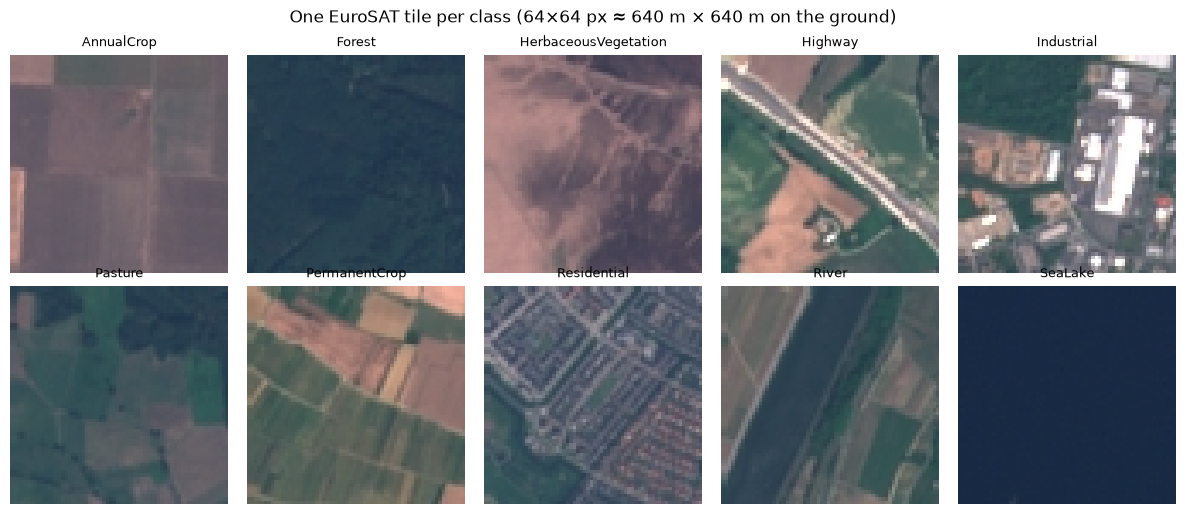

In [2]:
IMAGE_ROOT = download_eurosat(cfg.data_dir())          # downloads 94 MB the first time, then reuses the folder
samples = list_samples(IMAGE_ROOT)
counts = samples["label"].value_counts().reindex(list(cfg.CLASSES))
print(counts.to_string())
print(f"\n{len(samples):,} tiles | smallest class {counts.idxmin()} ({counts.min():,}) | largest {counts.idxmax()} ({counts.max():,})")

fig, axes = plt.subplots(2, 5, figsize=(12, 5.2))
for ax, name in zip(axes.flat, cfg.CLASSES):
    first = samples.loc[samples["label"] == name, "path"].iloc[0]
    show_tile(ax, to_uint8_tensor(decode_image_bytes((IMAGE_ROOT / first).read_bytes())), name, fontsize=9)
plt.suptitle("One EuroSAT tile per class (64×64 px ≈ 640 m × 640 m on the ground)")
plt.tight_layout()
plt.show()

The classes are **mildly imbalanced** (2,000–3,000 tiles each), so accuracy is informative, but we still report **macro-F1** and per-class recall so a weak small class can't hide behind the average. Some classes look alike even to people at this resolution: *AnnualCrop* vs *PermanentCrop* vs *HerbaceousVegetation*, and *Highway* vs *River* (long thin lines). Expect confusions there.

### ✍️ Your Turn

What accuracy would a model get by always predicting the **largest class**? Compute it from `counts`.

In [3]:
majority_accuracy = None  # TODO: largest class count / total count
check("majority_accuracy", majority_accuracy, counts.max() / counts.sum(), hint="counts.max() / counts.sum()")

⏳ majority_accuracy: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
majority_accuracy = counts.max() / counts.sum()
print(f"always predicting {counts.idxmax()}: {majority_accuracy:.1%} accuracy")
check("majority_accuracy", majority_accuracy, counts.max() / counts.sum())
```
</details>

> 💡 **Interview angle:** "What metric did you optimize and why?" — tie it to the product: macro-F1 and per-class recall because every land-use type matters, calibration because low-confidence tiles go to humans, and latency because it serves on CPU. Always state the trivial baseline first.

## Step 2. Stratified Splits Saved to Disk 🟢

We split **once**, stratified by class, **70% train / 15% validation / 15% test**, and save the file lists as CSVs with SHA-256 hashes. Saved splits mean every run, test, and teammate uses exactly the same images, and the metadata can prove which data a model saw.

We also save a fixed **quality subset**: 20 test tiles per class (200 total). The CI quality gate runs the exported model on it in seconds.

⚠️ **Honest caveat about leakage.** EuroSAT tiles are cut from larger satellite scenes, so neighbouring tiles of the same field or town can end up in different splits. A random split therefore measures "new tiles from familiar places". A stricter test for a new country would split by **geographic region**; EuroSAT's RGB release doesn't include coordinates, so we note this limitation instead of hiding it.

In [4]:
splits, split_hashes = prepare_data(cfg.data_dir(), seed=cfg.SEED)
overall_share = samples["label"].value_counts(normalize=True)
summary = pd.DataFrame({
    name: {"tiles": len(frame), "max class-share gap vs full data": (frame["label"].value_counts(normalize=True) - overall_share).abs().max(),
           "sha256": split_hashes[name][:12] + "…"}
    for name, frame in splits.items()}).T
print(summary.to_string())

paths = {name: set(splits[name]["path"]) for name in ("train", "validation", "test")}
assert not (paths["train"] & paths["validation"] or paths["train"] & paths["test"] or paths["validation"] & paths["test"])
assert set(splits["quality_subset"]["path"]) <= paths["test"]
print("✅ train/validation/test are disjoint; the quality subset comes from test:",
      splits["quality_subset"]["label"].value_counts().unique().tolist(), "tiles per class")

                tiles max class-share gap vs full data         sha256
train           18899                         0.000047  b00d2881ab3d…
validation       4051                         0.000219  54bb78173b0d…
test             4050                              0.0  7006bfc1ebec…
quality_subset    200                         0.025926  bcc403ccbb86…
✅ train/validation/test are disjoint; the quality subset comes from test: [20] tiles per class


> 💡 **Interview angle:** "How did you split image data?" — stratified by class, saved to disk with hashes, test touched once; and mention *group leakage*: near-duplicate or same-location images must stay in one split (group by scene, patient, user, or region).

## Step 3. Load Once, Augment on the Device 🟢

EuroSAT tiles are tiny, so we decode all of them **once** into `uint8` tensors (1 byte per value) with the same `to_uint8_tensor` function the API uses. Each training batch is moved to the GPU, scaled to `[0, 1]`, and augmented there. That avoids re-decoding 18,900 JPEGs every epoch and needs no data-loader worker processes.

**Augmentation** = random changes that don't change the label, so the model learns the land, not the pixel layout. For overhead imagery every **flip and 90° rotation** is valid (there is no "up"), plus a small **brightness** jitter for lighting and season differences. We avoid strong colour changes: colour is real signal here (water is blue, crops change colour with season).

decoded 27,000 tiles in 5.9 s | train (18899, 3, 64, 64) torch.uint8 | validation 4,051 | test 4,050
# image_classifier/src/image_classifier/transforms.py
def augment_batch(x: torch.Tensor, generator: torch.Generator | None = None, brightness: float = 0.1) -> torch.Tensor:
    """Per-image random horizontal/vertical flips, transpose (→ all 8 flips/90° rotations), and brightness jitter.

    Overhead imagery has no "up", so every rotation is a valid view of the same land. Random numbers are drawn on
    the CPU generator (reproducible), and the ops run on the batch's device (fast on a GPU).
    """
    n = x.shape[0]

    def coin() -> torch.Tensor:
        return (torch.rand(n, generator=generator) < 0.5).to(x.device).view(n, 1, 1, 1)

    x = torch.where(coin(), x.flip(-1), x)
    x = torch.where(coin(), x.flip(-2), x)
    x = torch.where(coin(), x.transpose(-1, -2), x)
    if brightness > 0:
        factor = 1 + (torch.rand(n, generator=generator) * 2 - 1) * brightness
        x = (x

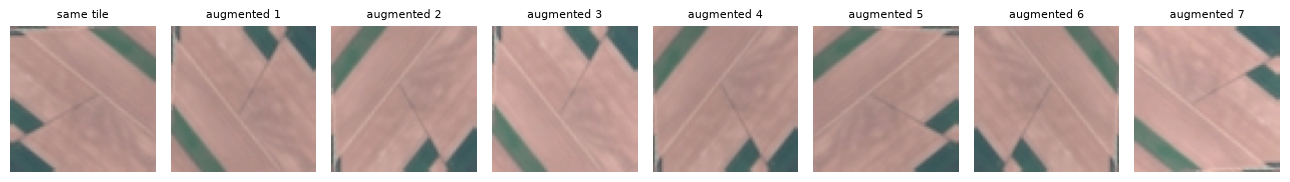

In [5]:
start = time.perf_counter()
train_x, train_y = load_images(splits["train"], IMAGE_ROOT)
val_x, val_y = load_images(splits["validation"], IMAGE_ROOT)
test_x, test_y = load_images(splits["test"], IMAGE_ROOT)                # 🔒 not used until 📏 Evaluation
print(f"decoded {len(train_x) + len(val_x) + len(test_x):,} tiles in {time.perf_counter() - start:.1f} s | "
      f"train {tuple(train_x.shape)} {train_x.dtype} | validation {len(val_x):,} | test {len(test_x):,}")
show_source(augment_batch, max_lines=25)

demo = train_x[:1].float().div(255).repeat(8, 1, 1, 1)
augmented = augment_batch(demo, torch.Generator().manual_seed(3))
fig, axes = plt.subplots(1, 8, figsize=(13, 2))
for i, ax in enumerate(axes):
    show_tile(ax, (augmented[i] * 255).round().to(torch.uint8), "same tile" if i == 0 else f"augmented {i}")
plt.tight_layout()
plt.show()

### ✍️ Your Turn

How many **megabytes** (1 MB = 10⁶ bytes) does `train_x` occupy? Use the number of elements and the bytes per element.

In [6]:
train_megabytes = None  # TODO: train_x.numel() × train_x.element_size() / 1e6
check("train_megabytes", train_megabytes, train_x.nbytes / 1e6, hint="uint8 uses 1 byte per element: train_x.numel() * train_x.element_size() / 1e6")

⏳ train_megabytes: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
train_megabytes = train_x.numel() * train_x.element_size() / 1e6
print(f"{train_megabytes:.0f} MB as uint8 — as float32 it would be {4 * train_megabytes:.0f} MB")
check("train_megabytes", train_megabytes, train_x.nbytes / 1e6)
```
</details>

> 💡 **Interview angle:** "Your GPU sits at 30% utilization during training — why?" — the input pipeline is the bottleneck (JPEG decoding, Python transforms, too few workers). Fixes: decode once or cache, move augmentation to the GPU, more DataLoader workers with `pin_memory`, bigger batches.

## Step 4. Baseline: A Small CNN From Scratch 🟡

A **baseline** tells us how much the fancy approach actually buys. `SmallCNN` has four convolution blocks (64 → 32 → 16 → 8 → 4 px), global average pooling, and a linear head: roughly 0.2 million parameters, no pretrained knowledge. It uses the same training loop as the real model:

- **AdamW** optimizer with weight decay,
- **one-cycle learning-rate schedule** — warm up to a peak, then anneal towards zero (fast, stable convergence in few epochs),
- **early stopping** on validation loss: keep the best epoch's weights and stop after `patience` epochs without improvement.

In [7]:
baseline_config = TrainConfig(epochs=4, max_lr=3e-3, patience=2)
torch.manual_seed(cfg.SEED)
baseline = SmallCNN(len(cfg.CLASSES))
print(f"SmallCNN: {count_parameters(baseline):,} parameters | {baseline_config}")
baseline_result = fit(baseline, train_x, train_y, val_x, val_y, baseline_config, DEVICE)
baseline_val_acc = baseline_result.history.loc[baseline_result.best_epoch - 1, "val_acc"]
print(f"baseline: best validation accuracy {baseline_val_acc:.4f} at epoch {baseline_result.best_epoch} in {baseline_result.seconds:.0f} s")

SmallCNN: 242,474 parameters | TrainConfig(epochs=4, batch_size=128, max_lr=0.003, body_lr_factor=0.1, weight_decay=0.0001, patience=2, label_smoothing=0.0, augment=True, seed=42)


epoch 1: train loss 1.0631 acc 0.6377 | val loss 1.0178 acc 0.6492 | 9.9 s ← best


epoch 2: train loss 0.6682 acc 0.7660 | val loss 0.5968 acc 0.7791 | 8.5 s ← best


epoch 3: train loss 0.4593 acc 0.8409 | val loss 0.3394 acc 0.8921 | 8.5 s ← best


epoch 4: train loss 0.3376 acc 0.8854 | val loss 0.2753 acc 0.9097 | 8.3 s ← best
baseline: best validation accuracy 0.9097 at epoch 4 in 35 s


> 💡 **Interview angle:** "Why train a baseline you won't ship?" — it calibrates expectations (is 97% impressive or trivial?), catches pipeline bugs (a baseline stuck at chance means broken labels or preprocessing), and justifies the cost of the bigger model with a number.

## Step 5. Transfer Learning: ResNet-18, Early Stopping, One-Cycle LR 🟡

**Transfer learning** reuses what a network learned on 1.28 million ImageNet photos: early layers detect edges and textures that are just as useful for fields and rivers. Our choices:

- **Upsample 64 → 96 px inside the model.** ResNet-18 shrinks images 32× by its last stage; at 64 px that stage would be a 2×2 grid. At 96 px it's 3×3 (and 6×6 one stage earlier), and an epoch still takes well under a minute on a laptop GPU (times are printed below). (Larger inputs, e.g. 224 px, are typically slightly more accurate and several times slower.)
- **ImageNet normalization inside the model**, so the exported file needs no separate preprocessing.
- **Fine-tune everything, but with discriminative learning rates:** the new head learns at `max_lr`, pretrained layers at `max_lr × 0.1` so their useful features aren't destroyed early on.

In [8]:
show_source(param_groups)
torch.manual_seed(cfg.SEED)
model = TransferResNet(len(cfg.CLASSES), input_size=96)
transfer_config = TrainConfig(epochs=6, max_lr=1e-3, body_lr_factor=0.1, patience=2)
print(f"ResNet-18 transfer model: {count_parameters(model):,} parameters | {transfer_config}")
result = fit(model, train_x, train_y, val_x, val_y, transfer_config, DEVICE)
model = result.model
transfer_val_acc = result.history.loc[result.best_epoch - 1, "val_acc"]
print(f"\ntransfer: best validation accuracy {transfer_val_acc:.4f} at epoch {result.best_epoch} in {result.seconds:.0f} s "
      f"({len(result.history)} epochs run)")
print(f"→ vs baseline {baseline_val_acc:.4f}: validation error falls from {1 - baseline_val_acc:.1%} to {1 - transfer_val_acc:.1%} "
      f"({(1 - baseline_val_acc) / max(1 - transfer_val_acc, 1e-9):.1f}× fewer mistakes)")
baseline = baseline_result.model.cpu()                       # keep for the final comparison, off the GPU
free_memory()

# image_classifier/src/image_classifier/train.py
def param_groups(model: nn.Module, config: TrainConfig) -> list[dict]:
    if hasattr(model, "head_parameters"):
        return [{"params": model.body_parameters(), "lr": config.max_lr * config.body_lr_factor},
                {"params": model.head_parameters(), "lr": config.max_lr}]
    return [{"params": list(model.parameters()), "lr": config.max_lr}]


ResNet-18 transfer model: 11,181,642 parameters | TrainConfig(epochs=6, batch_size=128, max_lr=0.001, body_lr_factor=0.1, weight_decay=0.0001, patience=2, label_smoothing=0.0, augment=True, seed=42)


epoch 1: train loss 1.0934 acc 0.6593 | val loss 0.1824 acc 0.9447 | 14.3 s ← best


epoch 2: train loss 0.1438 acc 0.9534 | val loss 0.1031 acc 0.9674 | 14.4 s ← best


epoch 3: train loss 0.0947 acc 0.9689 | val loss 0.0870 acc 0.9701 | 14.6 s ← best


epoch 4: train loss 0.0617 acc 0.9792 | val loss 0.0681 acc 0.9790 | 13.5 s ← best


epoch 5: train loss 0.0538 acc 0.9823 | val loss 0.0674 acc 0.9793 | 13.6 s ← best


epoch 6: train loss 0.0425 acc 0.9859 | val loss 0.0671 acc 0.9800 | 13.5 s ← best

transfer: best validation accuracy 0.9800 at epoch 6 in 84 s (6 epochs run)
→ vs baseline 0.9097: validation error falls from 9.0% to 2.0% (4.5× fewer mistakes)


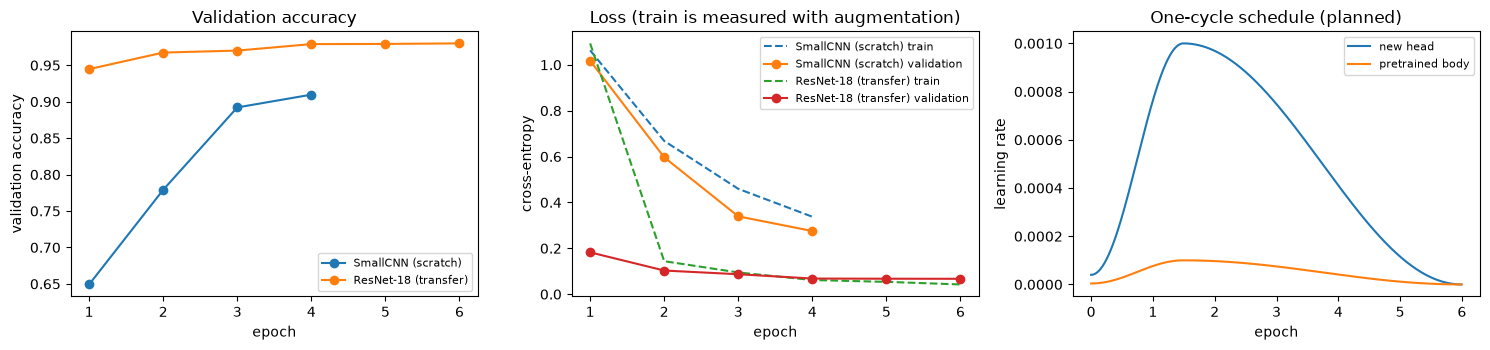

In [9]:
probe = torch.optim.AdamW(param_groups(TransferResNet(len(cfg.CLASSES), pretrained=False), transfer_config))
steps = transfer_config.epochs * math.ceil(len(train_x) / transfer_config.batch_size)
probe_schedule = OneCycleLR(probe, max_lr=[g["lr"] for g in probe.param_groups], total_steps=steps, pct_start=0.25)
lrs = []
for _ in range(steps):
    lrs.append([g["lr"] for g in probe.param_groups])
    probe.step()
    probe_schedule.step()
lrs = np.array(lrs)

fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
for name, fit_result in [("SmallCNN (scratch)", baseline_result), ("ResNet-18 (transfer)", result)]:
    h = fit_result.history
    axes[0].plot(h["epoch"], h["val_acc"], "o-", label=name)
    axes[1].plot(h["epoch"], h["train_loss"], "--", label=f"{name} train")
    axes[1].plot(h["epoch"], h["val_loss"], "o-", label=f"{name} validation")
axes[0].set(xlabel="epoch", ylabel="validation accuracy", title="Validation accuracy")
axes[1].set(xlabel="epoch", ylabel="cross-entropy", title="Loss (train is measured with augmentation)")
axes[2].plot(np.arange(steps) / (steps / transfer_config.epochs), lrs[:, 1], label="new head")
axes[2].plot(np.arange(steps) / (steps / transfer_config.epochs), lrs[:, 0], label="pretrained body")
axes[2].set(xlabel="epoch", ylabel="learning rate", title="One-cycle schedule (planned)")
for ax in axes:
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

Reading the curves: validation loss can be *below* training loss because training batches are augmented and dropout is on, while validation runs in eval mode on clean tiles. Early stopping keeps the epoch with the lowest validation loss; the schedule on the right is the plan for all epochs, which ends early if validation stops improving.

> 💡 **Interview angle:** "Freeze the backbone or fine-tune?" — tiny dataset or very similar domain: freeze and train the head (fast, less overfitting). More data or a different domain (satellite vs ImageNet photos): fine-tune with a lower learning rate for pretrained layers. Try head-only first as a cheap baseline.

## Step 6. Calibrate Confidence and Choose a Review Threshold 🟡

Deep networks trained with cross-entropy are often **over-confident**: they say 99% when they're right 95% of the time. **Temperature scaling** fixes this with one number $T$ fitted on the validation split: $\text{softmax}(\text{logits} / T)$. $T > 1$ softens the probabilities, $T < 1$ sharpens them. Dividing every logit by the same positive number never changes which class is largest, so **accuracy is unchanged**.

Then the product rule: **auto-accept** a prediction when its top-1 probability is at least a threshold, otherwise send the tile to a human. We pick the lowest threshold whose accepted **validation** predictions are at least **99%** accurate.

temperature T = 1.075 (softens over-confident probabilities)
validation accuracy 0.9800 | mean confidence raw 0.9821 → calibrated 0.9797
ECE raw 0.0066 → calibrated 0.0046 | NLL raw 0.0671 → calibrated 0.0667

review threshold (validation): auto-accept when top-1 probability ≥ 0.75
 threshold  coverage  accuracy_accepted  errors_accepted
      0.50    0.9970             0.9804               79
      0.80    0.9647             0.9908               36
      0.90    0.9425             0.9937               24
      0.75    0.9716             0.9901               39
      0.99    0.8339             0.9973                9


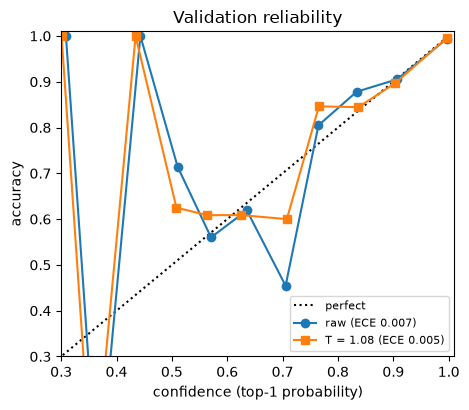

In [10]:
val_logits = predict_logits(model, val_x, DEVICE)
temperature = fit_temperature(val_logits, val_y)
val_raw = torch.softmax(val_logits, dim=1)
val_cal = torch.softmax(val_logits / temperature, dim=1)
assert torch.equal(val_raw.argmax(1), val_cal.argmax(1))
ece_raw, table_raw = expected_calibration_error(val_raw.numpy(), val_y.numpy())
ece_cal, table_cal = expected_calibration_error(val_cal.numpy(), val_y.numpy())
val_accuracy = (val_raw.argmax(1) == val_y).float().mean().item()
print(f"temperature T = {temperature:.3f} ({'softens over-confident' if temperature > 1 else 'sharpens under-confident'} probabilities)")
print(f"validation accuracy {val_accuracy:.4f} | mean confidence raw {val_raw.max(1).values.mean():.4f} → calibrated {val_cal.max(1).values.mean():.4f}")
print(f"ECE raw {ece_raw:.4f} → calibrated {ece_cal:.4f} | NLL raw {torch.nn.functional.cross_entropy(val_logits, val_y):.4f} "
      f"→ calibrated {torch.nn.functional.cross_entropy(val_logits / temperature, val_y):.4f}")

review_threshold = choose_review_threshold(val_cal.numpy(), val_y.numpy(), REVIEW_TARGET_ACCURACY)
print(f"\nreview threshold (validation): auto-accept when top-1 probability ≥ {review_threshold:.2f}")
print(coverage_table(val_cal.numpy(), val_y.numpy(), thresholds=(0.5, 0.8, 0.9, review_threshold, 0.99)).round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(4.8, 4.2))
ax.plot([0, 1], [0, 1], "k:", label="perfect")
ax.plot(table_raw["mean_confidence"], table_raw["accuracy"], "o-", label=f"raw (ECE {ece_raw:.3f})")
ax.plot(table_cal["mean_confidence"], table_cal["accuracy"], "s-", label=f"T = {temperature:.2f} (ECE {ece_cal:.3f})")
ax.set(xlabel="confidence (top-1 probability)", ylabel="accuracy", title="Validation reliability", xlim=(0.3, 1.01), ylim=(0.3, 1.01))
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### ✍️ Your Turn

What share of validation tiles would go to a **human** under the chosen review threshold? (Share with top-1 calibrated probability below `review_threshold`.)

In [11]:
share_to_human = None  # TODO: (val_cal.max(dim=1).values < review_threshold).float().mean().item()
check("share_to_human", share_to_human, (val_cal.max(dim=1).values < review_threshold).float().mean().item(),
      hint="Take the max probability per row with .max(dim=1).values, compare with the threshold, and average the booleans.")

⏳ share_to_human: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
share_to_human = (val_cal.max(dim=1).values < review_threshold).float().mean().item()
print(f"{share_to_human:.1%} of tiles need a human; the rest are auto-accepted")
check("share_to_human", share_to_human, (val_cal.max(dim=1).values < review_threshold).float().mean().item())
```
</details>

> 💡 **Interview angle:** "How do you let a model say 'I don't know'?" — calibrate on held-out data (temperature scaling), then choose a confidence threshold from a coverage-vs-accuracy table on validation to meet a target accuracy, and route the rest to humans. Monitor the human-review rate in production.

## Step 7. Export With torch.export and Measure Latency 🟡

`torch.export.export` traces the model into an **ExportedProgram**: a graph of standard PyTorch operators with the weights, saved as a `.pt2` file. Loading it needs neither our `TransferResNet` class nor torchvision. We mark the batch dimension as **dynamic** so the same file serves batch 1 and batch 256. (`torch.export` replaces TorchScript, which is deprecated.)

Then we measure latency the honest way: warm-up runs, GPU synchronization before reading the clock, many repeats, **p50 and p95**, and the **preprocessing** cost (decode the JPEG bytes + convert) that every request also pays.

In [12]:
start = time.perf_counter()
exported = export_model(model)
step7_path = OUTPUT_DIR / "resnet18_eurosat_step7.pt2"
torch.export.save(exported, step7_path)
program = torch.export.load(step7_path).module()
print(f"exported + saved + reloaded in {time.perf_counter() - start:.1f} s | graph nodes {len(list(exported.graph.nodes))} | "
      f"file {step7_path.stat().st_size / 1e6:.1f} MB")

cpu_model = copy.deepcopy(model).cpu().eval()
with torch.inference_mode():
    for batch_size in (1, 7, 64):
        x = val_x[:batch_size].float().div(255)
        diff = (program(x) - cpu_model(x)).abs().max().item()
        print(f"batch {batch_size:3d}: max |exported − eager| = {diff:.2e}")
        assert diff < 1e-3

if importlib.util.find_spec("onnx") and importlib.util.find_spec("onnxscript"):
    onnx_program = torch.onnx.export(cpu_model, (val_x[:2].float().div(255),), dynamo=True)
    onnx_program.save(OUTPUT_DIR / "resnet18_eurosat.onnx")
    print("ONNX export saved to", rel(OUTPUT_DIR / "resnet18_eurosat.onnx"))
else:
    print("⏭️ Skipped ONNX export: the `onnx` and `onnxscript` packages are not installed. To try it:\n"
          "   pip install onnx onnxscript onnxruntime\n"
          "   torch.onnx.export(cpu_model, (example_batch,), dynamo=True).save('model.onnx')")

exported + saved + reloaded in 0.7 s | graph nodes 199 | file 45.2 MB
batch   1: max |exported − eager| = 0.00e+00
batch   7: max |exported − eager| = 0.00e+00


batch  64: max |exported − eager| = 0.00e+00


[torch.onnx] Obtain model graph for `TransferResNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `TransferResNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
ONNX export saved to _outputs/image_classifier/resnet18_eurosat.onnx


In [13]:
tile_bytes = [(IMAGE_ROOT / path).read_bytes() for path in splits["validation"]["path"].head(300)]
prep_times = []
for data in tile_bytes:
    t0 = time.perf_counter()
    to_uint8_tensor(decode_image_bytes(data)).unsqueeze(0).float().div(255)
    prep_times.append((time.perf_counter() - t0) * 1000)
prep_p50, prep_p95 = np.percentile(prep_times, [50, 95])

one, thirty_two = torch.rand(1, 3, 64, 64), torch.rand(32, 3, 64, 64)
rows = [
    {"setup": "CPU eager, batch 1", **measure_latency(cpu_model, one, CPU)},
    {"setup": "CPU torch.export, batch 1", **measure_latency(program, one, CPU)},
    {"setup": "CPU torch.export, batch 32", **measure_latency(program, thirty_two, CPU, repeats=15)},
]
if DEVICE.type != "cpu":
    model.eval()
    rows += [{"setup": f"{DEVICE.type.upper()} eager, batch 1", **measure_latency(model, one, DEVICE)},
             {"setup": f"{DEVICE.type.upper()} eager, batch 32", **measure_latency(model, thirty_two, DEVICE, repeats=15)}]
else:
    print("⏭️ Skipped GPU rows: no GPU on this machine.")
latency = pd.DataFrame(rows).set_index("setup")
print(latency.round(2).to_string())
print(f"\npreprocessing (decode JPEG + convert) per tile: p50 {prep_p50:.2f} ms, p95 {prep_p95:.2f} ms")
cpu_p95_total = latency.loc["CPU torch.export, batch 1", "p95_ms"] + prep_p95
print(f"CPU serving estimate p95 ≈ model {latency.loc['CPU torch.export, batch 1', 'p95_ms']:.1f} ms + preprocessing {prep_p95:.1f} ms "
      f"= {cpu_p95_total:.1f} ms → criterion 4 (≤ 50 ms): {'✅ met' if cpu_p95_total <= 50 else '❌ not met'}")
if DEVICE.type != "cpu":
    gpu = DEVICE.type.upper()
    print(f"batch 32 vs batch 1 throughput — CPU {latency.loc['CPU torch.export, batch 32', 'images_per_s'] / latency.loc['CPU torch.export, batch 1', 'images_per_s']:.1f}× | "
          f"{gpu} {latency.loc[f'{gpu} eager, batch 32', 'images_per_s'] / latency.loc[f'{gpu} eager, batch 1', 'images_per_s']:.1f}×")

                            p50_ms  p95_ms  images_per_s
setup                                                   
CPU eager, batch 1            3.13    3.21        318.80
CPU torch.export, batch 1     3.21    3.31        311.49
CPU torch.export, batch 32  113.92  116.74        279.60
MPS eager, batch 1            1.96    2.16        505.04
MPS eager, batch 32           6.37    6.54       5005.51

preprocessing (decode JPEG + convert) per tile: p50 0.05 ms, p95 0.05 ms
CPU serving estimate p95 ≈ model 3.3 ms + preprocessing 0.1 ms = 3.4 ms → criterion 4 (≤ 50 ms): ✅ met
batch 32 vs batch 1 throughput — CPU 0.9× | MPS 9.9×


Read the table rather than rules of thumb: at batch 1 a laptop CPU and GPU are in the same range for a small model, because per-call overhead dominates; the GPU pulls far ahead on **throughput** at larger batches, while a CPU often gains little or nothing from batching. Exporting is mainly about **portability** (a Python-class-free artifact for serving, mobile via ExecuTorch, or compilation with AOTInductor); speedups come from what you do with the graph. Timings on a laptop shared with other programs vary between runs.

> 💡 **Interview angle:** "How would you make inference faster?" — measure first (p50/p95 at the real batch size, including preprocessing), then: smaller input or model, export + compile (AOTInductor/TensorRT), int8 quantization, dynamic batching on GPU, and more CPU replicas with few threads each.

## 📏 Evaluation

Everything is frozen: weights, temperature, review threshold. We score the **test split once**, using the **exported program on the CPU** — exactly what the service will run — and check it agrees with the eager GPU model. Every headline number gets a **95% bootstrap confidence interval** (resample the 4,050 test tiles 1,000 times).

In [14]:
start = time.perf_counter()
with torch.inference_mode():
    shipped_logits = torch.cat([program(test_x[i:i + 256].float().div(255)) for i in range(0, len(test_x), 256)])
eager_logits = predict_logits(model, test_x, DEVICE)
agreement = (shipped_logits.argmax(1) == eager_logits.argmax(1)).float().mean().item()
baseline_test_logits = predict_logits(baseline, test_x, CPU)
print(f"scored {len(test_x):,} test tiles in {time.perf_counter() - start:.1f} s | exported (CPU) vs eager ({DEVICE.type}) top-1 agreement {agreement:.4%}")

test_metrics = summarize_test(shipped_logits, test_y, temperature, n_boot=1000, seed=cfg.SEED)
test_pred = shipped_logits.argmax(1).numpy()
baseline_acc = (baseline_test_logits.argmax(1) == test_y).float().mean().item()
acc, f1 = test_metrics["accuracy"], test_metrics["macro_f1"]
print(f"TEST accuracy {acc['estimate']:.4f} (95% CI {acc['ci_low']:.4f}–{acc['ci_high']:.4f}) | "
      f"macro-F1 {f1['estimate']:.4f} (95% CI {f1['ci_low']:.4f}–{f1['ci_high']:.4f})")
print(f"baseline SmallCNN test accuracy {baseline_acc:.4f} | ECE raw {test_metrics['ece_raw']:.4f} → calibrated {test_metrics['ece_calibrated']:.4f}")

per_class = per_class_table(test_y.numpy(), test_pred, cfg.CLASSES)
print("\n" + per_class.round(4).to_string())

test_probs = torch.softmax(shipped_logits / temperature, dim=1).numpy()
review = coverage_table(test_probs, test_y.numpy(), thresholds=(review_threshold,)).iloc[0]
criteria = pd.DataFrame([
    {"criterion": "1. macro-F1 ≥ 0.95", "value": f1["estimate"], "met": f1["estimate"] >= 0.95},
    {"criterion": "2. every class recall ≥ 0.90", "value": per_class["recall"].min(), "met": per_class["recall"].min() >= 0.90},
    {"criterion": "3. calibrated ECE ≤ 0.03", "value": test_metrics["ece_calibrated"], "met": test_metrics["ece_calibrated"] <= 0.03},
    {"criterion": "4. CPU p95 ≤ 50 ms (model + preprocessing)", "value": cpu_p95_total, "met": cpu_p95_total <= 50},
    {"criterion": "5. training ≈ 10 min", "value": (baseline_result.seconds + result.seconds) / 60, "met": (baseline_result.seconds + result.seconds) / 60 <= 12},
]).set_index("criterion")
print("\n" + criteria.round(4).to_string())
print(f"\nreview rule on TEST (threshold {review_threshold:.2f} chosen on validation): {review['coverage']:.1%} auto-accepted with "
      f"{review['accuracy_accepted']:.2%} accuracy ({int(review['errors_accepted'])} wrong labels slip through); "
      f"{1 - review['coverage']:.1%} go to a human")

scored 4,050 test tiles in 15.0 s | exported (CPU) vs eager (mps) top-1 agreement 100.0000%


TEST accuracy 0.9775 (95% CI 0.9728–0.9820) | macro-F1 0.9770 (95% CI 0.9724–0.9814)
baseline SmallCNN test accuracy 0.9143 | ECE raw 0.0041 → calibrated 0.0043

                      precision  recall      f1  support
AnnualCrop               0.9817  0.9511  0.9661      450
Forest                   1.0000  0.9933  0.9967      450
HerbaceousVegetation     0.9477  0.9667  0.9571      450
Highway                  0.9814  0.9840  0.9827      375
Industrial               0.9920  0.9920  0.9920      375
Pasture                  0.9702  0.9767  0.9734      300
PermanentCrop            0.9335  0.9360  0.9348      375
Residential              0.9912  0.9978  0.9945      450
River                    0.9735  0.9813  0.9774      375
SeaLake                  0.9978  0.9933  0.9955      450

                                             value   met
criterion                                               
1. macro-F1 ≥ 0.95                          0.9770  True
2. every class recall ≥ 0.90           

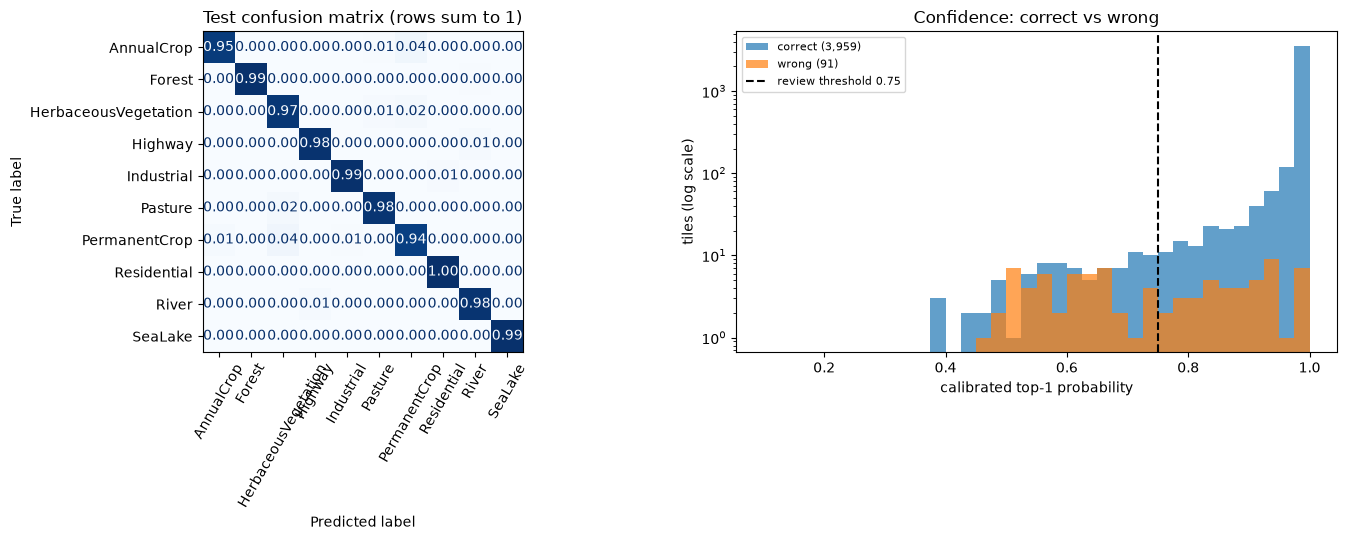

                true            predicted  count  share_of_true_class
       PermanentCrop HerbaceousVegetation     16                0.043
          AnnualCrop        PermanentCrop     16                0.036
HerbaceousVegetation        PermanentCrop      8                0.018
               River              Highway      5                0.013
HerbaceousVegetation              Pasture      5                0.011
             Highway                River      5                0.013


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), gridspec_kw={"width_ratios": [1.3, 1]})
ConfusionMatrixDisplay.from_predictions(test_y.numpy(), test_pred, display_labels=list(cfg.CLASSES), normalize="true",
                                        values_format=".2f", cmap="Blues", colorbar=False, ax=axes[0], xticks_rotation=60)
axes[0].set_title("Test confusion matrix (rows sum to 1)")
confidence = test_probs.max(axis=1)
correct = test_pred == test_y.numpy()
bins = np.linspace(0.1, 1, 37)
axes[1].hist(confidence[correct], bins=bins, alpha=0.7, label=f"correct ({correct.sum():,})")
axes[1].hist(confidence[~correct], bins=bins, alpha=0.7, label=f"wrong ({(~correct).sum():,})")
axes[1].axvline(review_threshold, color="black", ls="--", label=f"review threshold {review_threshold:.2f}")
axes[1].set(yscale="log", xlabel="calibrated top-1 probability", ylabel="tiles (log scale)", title="Confidence: correct vs wrong")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()
print(top_confusions(test_y.numpy(), test_pred, cfg.CLASSES, k=6).round(3).to_string(index=False))

**Error analysis.** Numbers tell you *how often* the model fails; looking at the failures tells you *why*. Below are the most **confident mistakes** (the dangerous ones: they would be auto-accepted if above the threshold), then **Grad-CAM** heatmaps for correct and wrong predictions. Grad-CAM uses `layer3` (a 6×6 grid at our 96 px input) because `layer4`'s 3×3 grid is too coarse to show anything on a 64-px tile.

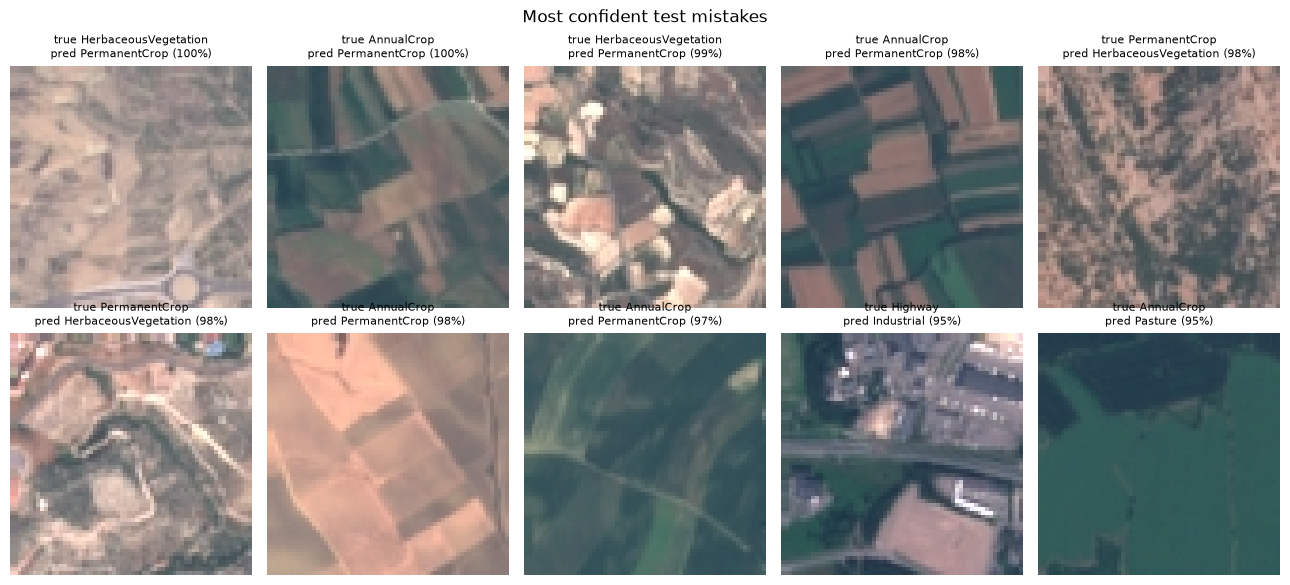

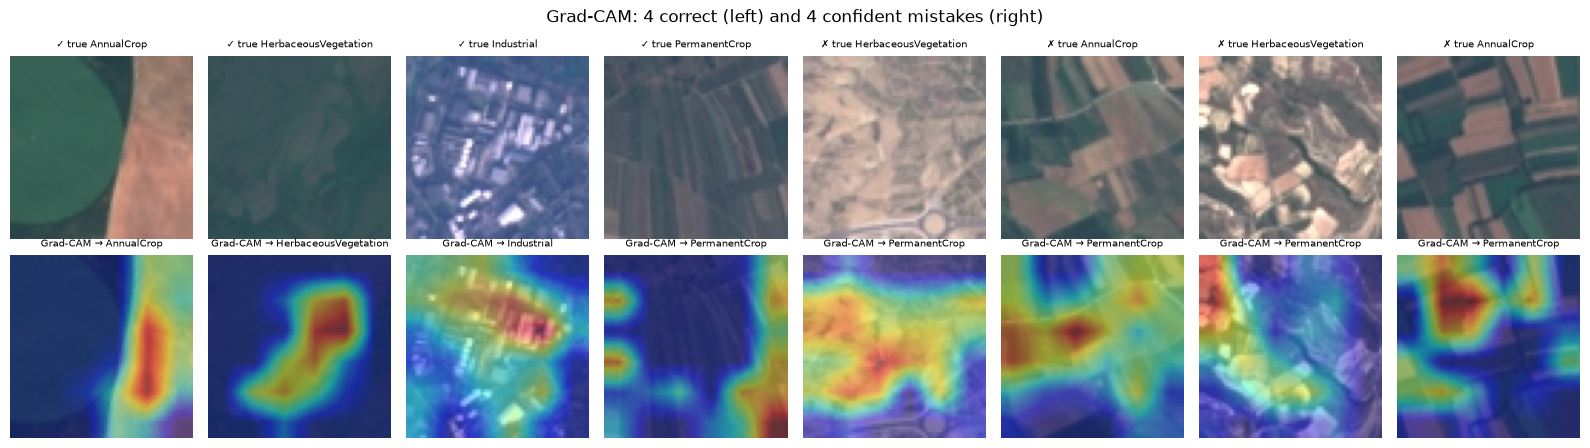

In [16]:
wrong_idx = np.flatnonzero(~correct)
confident_wrong = wrong_idx[np.argsort(-confidence[wrong_idx])][:10]
fig, axes = plt.subplots(2, 5, figsize=(13, 6))
for ax, i in zip(axes.flat, confident_wrong):
    show_tile(ax, test_x[i], f"true {cfg.CLASSES[test_y[i]]}\npred {cfg.CLASSES[test_pred[i]]} ({confidence[i]:.0%})")
plt.suptitle("Most confident test mistakes")
plt.tight_layout()
plt.show()

right_idx = np.flatnonzero(correct)
chosen_right = [right_idx[test_y.numpy()[right_idx] == c][0] for c in range(0, len(cfg.CLASSES), 2)][:4]
chosen = [*chosen_right, *confident_wrong[:4]]
model.eval()
with GradCAM(model, model.backbone.layer3) as cam_tool:
    cams, cam_logits, cam_classes = cam_tool(test_x[chosen].float().div(255).to(DEVICE))
fig, axes = plt.subplots(2, 8, figsize=(16, 4.6))
for column, i in enumerate(chosen):
    status = "✓" if correct[i] else "✗"
    show_tile(axes[0, column], test_x[i], f"{status} true {cfg.CLASSES[test_y[i]]}", fontsize=7)
    axes[1, column].imshow(test_x[i].permute(1, 2, 0).numpy())
    axes[1, column].imshow(cams[column].cpu().numpy(), cmap="jet", alpha=0.45)
    axes[1, column].set_title(f"Grad-CAM → {cfg.CLASSES[cam_classes[column]]}", fontsize=7)
    axes[1, column].axis("off")
plt.suptitle("Grad-CAM: 4 correct (left) and 4 confident mistakes (right)")
plt.tight_layout()
plt.show()
free_memory()

How to read these: check whether the confident mistakes are **label-ambiguous** (a tile that honestly contains both a river and a field, or crops that look like pasture at 10 m resolution) or **model failures** (the heatmap focuses on something irrelevant like a dark corner). Ambiguous tiles argue for multi-label annotations or accepting some human review; model failures argue for more data of that kind or stronger augmentation. Grad-CAM is coarse and can look plausible even for a weak model, so treat it as a debugging hint, not proof.

### ✍️ Your Turn

Which class has the **lowest test recall**? Return its name as a string from `per_class`.

In [17]:
weakest_class = None  # TODO: per_class["recall"].idxmin()
check("weakest_class", weakest_class, per_class["recall"].idxmin(), hint="per_class is indexed by class name: use .idxmin() on the recall column.")

⏳ weakest_class: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
weakest_class = per_class["recall"].idxmin()
print(weakest_class, per_class.loc[weakest_class].round(3).to_dict())
check("weakest_class", weakest_class, per_class["recall"].idxmin())
```
</details>

> 💡 **Interview angle:** "Your model is 97% accurate. What would you do next?" — look at the errors: per-class recall, the confusion pairs, the most confident mistakes, Grad-CAM on them; decide whether it's label noise, genuine ambiguity, or a data gap, and fix *that* (relabel, collect, augment), rather than blindly training a bigger model.

## 🚢 Deployment

The evaluated model meets (or honestly misses — see the criteria table) our targets, so we ship it through the project folder [`image_classifier/`](image_classifier/README.md). Each subsection runs the real thing.

### 1. Save the bundle: model.pt2 + metadata.json

The metadata makes the artifact self-describing: version (from a hash of the weights), classes, temperature, review threshold, split hashes, training history, test metrics with CIs, and the PyTorch version that exported it.

In [18]:
split_sizes = {name: len(frame) for name, frame in splits.items()}
metadata = build_metadata(model=model, config=transfer_config, result=result, temperature=temperature, review_threshold=review_threshold,
                          split_hashes=split_hashes, split_sizes=split_sizes, test_metrics=test_metrics, device=DEVICE)
bundle_paths, metadata = save_bundle(model, metadata, cfg.artifacts_dir())
for path in bundle_paths.values():
    print(f"{rel(path):50s} {path.stat().st_size / 1024:9.1f} KB")
print(json.dumps({k: metadata[k] for k in ["model_version", "architecture", "temperature", "review_threshold", "torch_version"]}, indent=2))

classifier = ImageClassifier.load(cfg.artifacts_dir())
reloaded = classifier.predict_proba(test_x[:512])
assert torch.equal(reloaded.argmax(1), shipped_logits[:512].argmax(1))
assert torch.allclose(reloaded, torch.softmax(shipped_logits[:512] / temperature, 1), atol=1e-5)
print(f"✅ ImageClassifier.load reproduces the evaluated predictions (model {classifier.version})")

files = sorted(p for p in PROJECT_DIR.rglob("*") if p.is_file() and not {"data", "__pycache__", ".pytest_cache", ".ruff_cache"} & set(p.relative_to(PROJECT_DIR).parts))
print("\nproject files:\n  " + "\n  ".join(str(p.relative_to(PROJECT_DIR)) for p in files))

image_classifier/artifacts/model.pt2                 44091.0 KB
image_classifier/artifacts/metadata.json                 3.6 KB
{
  "model_version": "1.0.0+a52aa97c",
  "architecture": "TransferResNet (input upsampled to 96 px inside the model)",
  "temperature": 1.075035572052002,
  "review_threshold": 0.75,
  "torch_version": "2.14.0"
}


✅ ImageClassifier.load reproduces the evaluated predictions (model 1.0.0+a52aa97c)



project files:
  .dockerignore
  .gitignore
  Dockerfile
  README.md
  artifacts/metadata.json
  artifacts/model.pt2
  ci/github-actions.yml
  pyproject.toml
  requirements.lock
  src/image_classifier/__init__.py
  src/image_classifier/api.py
  src/image_classifier/config.py
  src/image_classifier/data.py
  src/image_classifier/evaluate.py
  src/image_classifier/export.py
  src/image_classifier/gradcam.py
  src/image_classifier/models.py
  src/image_classifier/predict.py
  src/image_classifier/train.py
  src/image_classifier/transforms.py
  tests/conftest.py
  tests/test_api.py
  tests/test_model_quality.py
  tests/test_transforms.py


### 2. The upload service

`api.py` defines `POST /predict` for a multipart file upload. Validation happens in cheap-to-expensive order, each with the right HTTP status:

| Check | Status |
|---|---|
| content type is `image/jpeg` or `image/png` | 415 Unsupported Media Type |
| at most 5 MB (read at most limit + 1 bytes) | 413 Content Too Large |
| decodes as the **declared** format, ≤ 25 megapixels (checked from the header before decoding: "decompression bombs") | 400 Bad Request |
| `k` between 1 and 10 | 422 Unprocessable Content |

The endpoint is `async` (it awaits the upload), so the CPU-bound model call runs in a **thread pool** (`run_in_threadpool`) to keep the event loop responsive. The response has calibrated top-k probabilities, `needs_review`, and the model version.

In [19]:
from fastapi.testclient import TestClient  # noqa: E402

from image_classifier.api import create_app  # noqa: E402

show_source(create_app, start_at='@app.post("/predict"', max_lines=30)

sample_row = splits["test"].iloc[0]
sample_bytes = (IMAGE_ROOT / sample_row["path"]).read_bytes()
with TestClient(create_app(cfg.artifacts_dir())) as client:
    response = client.post("/predict", files={"file": ("tile.jpg", sample_bytes, "image/jpeg")}, params={"k": 3})
    print(f"true label {sample_row['label']} →", response.status_code, response.json())
    rejections = {
        "text file": client.post("/predict", files={"file": ("notes.txt", b"hello", "text/plain")}),
        "truncated JPEG": client.post("/predict", files={"file": ("tile.jpg", sample_bytes[:300], "image/jpeg")}),
        "k = 0": client.post("/predict", files={"file": ("tile.jpg", sample_bytes, "image/jpeg")}, params={"k": 0}),
        "6 MB upload": client.post("/predict", files={"file": ("big.png", b"0" * 6_000_000, "image/png")}),
    }
for name, reply in rejections.items():
    detail = reply.json()["detail"]
    print(f"{name:15s} → {reply.status_code} {detail if isinstance(detail, str) else detail[0]['msg']}")

# image_classifier/src/image_classifier/api.py
    @app.post("/predict", response_model=PredictionResponse)
    async def predict(
        classifier: ClassifierDep,
        file: Annotated[UploadFile, File(description="a JPEG or PNG image (EuroSAT tiles are 64×64 RGB)")],
        k: Annotated[int, Query(ge=1, le=cfg.MAX_TOP_K, description="number of classes to return")] = 3,
    ) -> PredictionResponse:
        if file.content_type not in cfg.ALLOWED_CONTENT_TYPES:
            raise HTTPException(status_code=415, detail=f"content type {file.content_type!r} not supported; use image/jpeg or image/png")
        data = await file.read(cfg.MAX_UPLOAD_BYTES + 1)
        if len(data) > cfg.MAX_UPLOAD_BYTES:
            raise HTTPException(status_code=413, detail=f"file larger than {cfg.MAX_UPLOAD_BYTES:,} bytes")
        try:
            image = decode_image_bytes(data, allowed_formats=(cfg.ALLOWED_CONTENT_TYPES[file.content_type],))
        except InvalidImageError as err:
            raise

true label AnnualCrop → 200 {'model_version': '1.0.0+a52aa97c', 'filename': 'tile.jpg', 'top_k': [{'label': 'AnnualCrop', 'probability': 0.9999947547912598}, {'label': 'Pasture', 'probability': 4.01499437430175e-06}, {'label': 'PermanentCrop', 'probability': 6.546183612954337e-07}], 'needs_review': False, 'inference_ms': 4.58}
text file       → 415 content type 'text/plain' not supported; use image/jpeg or image/png
truncated JPEG  → 400 not a readable image
k = 0           → 422 Input should be greater than or equal to 1
6 MB upload     → 413 file larger than 5,242,880 bytes


### 3. Run the test suite

- `test_transforms.py` — any image mode/size → `(3, 64, 64)` uint8; lossless PNG isn't resampled; invalid, truncated, oversized, and wrong-format bytes raise; augmentation only moves pixels and is reproducible.
- `test_api.py` — runs against a **tiny exported model** created in a temp folder (seconds, no data or GPU): health/readiness, sorted top-k, `needs_review`, API output = offline prediction, all rejections, 503 without a model.
- `test_model_quality.py` (marker `quality`) — the **real** exported model on the fixed 200-tile subset: accuracy ≥ **0.90**, every class recall ≥ **0.70**, and the subset's hash must match the metadata.

In [20]:
tests = run([sys.executable, "-m", "pytest", "-q", "-rA", "-p", "no:cacheprovider"], max_lines=35)
assert tests.returncode == 0, "tests failed"
n_tests_passed = int(re.search(r"(\d+) passed", tests.stdout).group(1))
print(f"✅ {n_tests_passed} tests passed (including the model-quality gate)")

$ python -m pytest -q -rA -p no:cacheprovider


  ...................                                                      [100%]
  ==================================== PASSES ====================================
  ____________ test_service_without_artifacts_is_alive_but_not_ready _____________
  ------------------------------ Captured log call -------------------------------
  ERROR    uvicorn.error:api.py:59 model not loaded: model.pt2 not found in the artifacts directory — train and export a model first
  =========================== short test summary info ============================
  PASSED tests/test_api.py::test_health_ready_and_model_info
  PASSED tests/test_api.py::test_prediction_returns_sorted_top_k[PNG-image/png]
  PASSED tests/test_api.py::test_prediction_returns_sorted_top_k[JPEG-image/jpeg]
  PASSED tests/test_api.py::test_all_classes_sum_to_one_and_match_offline_prediction
  PASSED tests/test_api.py::test_k_out_of_range_is_422[0]
  PASSED tests/test_api.py::test_k_out_of_range_is_422[11]
  PASSED tests/test_api.py::

### 4. A real server and real uploads

Start uvicorn in a background process, upload 60 real test tiles one by one, and measure end-to-end latency (HTTP + decode + model on CPU).

In [21]:
upload_rows = splits["test"].sample(n=60, random_state=cfg.SEED)
with UvicornServer("image_classifier.api:app", cwd=PROJECT_DIR, env={"PYTHONPATH": str(PROJECT_DIR / "src")}) as server:
    print(f"server ready in {server.startup_seconds:.1f} s")
    latencies, served_labels, served_review = [], [], []
    with httpx.Client(base_url=server.base_url, timeout=30) as http:
        for _, row in upload_rows.iterrows():
            data = (IMAGE_ROOT / row["path"]).read_bytes()
            t0 = time.perf_counter()
            reply = http.post("/predict", files={"file": (Path(row["path"]).name, data, "image/jpeg")}, params={"k": 1})
            latencies.append((time.perf_counter() - t0) * 1000)
            assert reply.status_code == 200
            served_labels.append(reply.json()["top_k"][0]["label"])
            served_review.append(reply.json()["needs_review"])
served_accuracy = np.mean(np.array(served_labels) == upload_rows["label"].to_numpy())
offline = [cfg.CLASSES[i] for i in classifier.predict_proba(load_images(upload_rows, IMAGE_ROOT)[0]).argmax(1).tolist()]
print(f"HTTP latency p50 {np.percentile(latencies, 50):.1f} ms, p95 {np.percentile(latencies, 95):.1f} ms | "
      f"accuracy on these 60 tiles {served_accuracy:.1%} | flagged for review {np.mean(served_review):.1%}")
assert served_labels == offline
print("✅ served labels equal offline predictions for all 60 uploads")
print("--- server log (first lines) ---")
print("\n".join(server.log_text().splitlines()[:4]))

server ready in 1.3 s


HTTP latency p50 4.4 ms, p95 4.7 ms | accuracy on these 60 tiles 100.0% | flagged for review 0.0%
✅ served labels equal offline predictions for all 60 uploads
--- server log (first lines) ---
INFO:     Started server process [99723]
INFO:     Waiting for application startup.
INFO:     loaded model 1.0.0+a52aa97c with 10 classes
INFO:     Application startup complete.


### 5. The training CLI (smoke run)

`python -m image_classifier.train` runs the whole pipeline — data, fine-tuning, temperature, review threshold, single test evaluation, export — which is how you'd retrain on a GPU machine. Here we only **smoke-test** it: 1 epoch on 1,500 training tiles into a scratch folder, to prove the command works end to end. Its accuracy is not the product's.

In [22]:
smoke_dir = OUTPUT_DIR / "smoke_artifacts"
shutil.rmtree(smoke_dir, ignore_errors=True)
smoke = run([sys.executable, "-m", "image_classifier.train", "--epochs", "1", "--max-train-images", "1500", "--artifacts-dir", smoke_dir],
            env={"PYTHONPATH": str(PROJECT_DIR / "src")}, max_lines=6)
assert smoke.returncode == 0 and (smoke_dir / "model.pt2").is_file()
smoke_meta = json.loads((smoke_dir / "metadata.json").read_text())
print(f"✅ CLI smoke run wrote {smoke_meta['model_version']} (1 epoch, {smoke_meta['data']['splits']['train']['rows']:,} tiles): "
      f"test accuracy {smoke_meta['test_metrics']['accuracy']['estimate']:.3f} vs the real model's {acc['estimate']:.3f}")

$ python -m image_classifier.train --epochs 1 --max-train-images 1500 --artifacts-dir _outputs/image_classifier/smoke_artifacts


  device mps | train 1,500 | validation 4,051 | test 4,050 images
  epoch 1: train loss 1.8673 acc 0.3893 | val loss 1.4176 acc 0.6157 | 2.6 s ← best
  saved 1.0.0+c6e673f9 | test accuracy 0.6138 | temperature 0.447
  [exit code 0 · 10.5 s]
✅ CLI smoke run wrote 1.0.0+c6e673f9 (1 epoch, 1,500 tiles): test accuracy 0.614 vs the real model's 0.978


### 6. A CPU-only Docker image

Serving doesn't need a GPU, and CUDA builds of PyTorch add gigabytes. The [`Dockerfile`](image_classifier/Dockerfile) installs **CPU wheels** from PyTorch's CPU index, pinned in `requirements.lock` to the version that exported the model, in a builder stage. The runtime stage copies only the virtual environment, the package, `model.pt2`, and `metadata.json`; it runs as a non-root user with a health check on `/ready`. `OMP_NUM_THREADS=2` stops PyTorch from starting one thread per host core in every container replica.

In [23]:
print((PROJECT_DIR / "Dockerfile").read_text())


def docker_status():
    if DOCKER is None:
        return False, "the docker command is not installed"
    try:
        probe = subprocess.run([DOCKER, "info", "--format", "{{.ServerVersion}}"], capture_output=True, text=True, timeout=60)
    except subprocess.TimeoutExpired:
        return False, "the Docker daemon did not answer within 60 s"
    if probe.returncode == 0 and probe.stdout.strip():
        return True, probe.stdout.strip()
    # don't echo docker's error text: it can contain local socket paths with your username
    return False, "the Docker daemon is not reachable (`docker info` failed): start Docker Desktop or the Docker service"


DOCKER_OK, DOCKER_INFO = docker_status()
IMAGE = f"image-classifier:{metadata['model_version'].replace('+', '-')}"
print(f"Docker available: {DOCKER_OK} ({DOCKER_INFO})")

# syntax=docker/dockerfile:1
# CPU-only PyTorch serving image. Export a model first (artifacts/model.pt2 + metadata.json), then:
#   docker build -t image-classifier:1.0.0 .
#   docker run --rm -p 8000:8000 image-classifier:1.0.0

# ---------- stage 1: builder ----------
FROM python:3.12-slim AS builder
COPY --from=ghcr.io/astral-sh/uv:0.10.3 /uv /bin/uv
ENV UV_COMPILE_BYTECODE=1 UV_LINK_MODE=copy UV_PYTHON_DOWNLOADS=never
WORKDIR /build
COPY requirements.lock ./
# The CPU wheel index keeps CUDA libraries (several GB) out of the image
RUN --mount=type=cache,target=/root/.cache/uv \
    uv venv /opt/venv && \
    uv pip install --python /opt/venv/bin/python -r requirements.lock \
        --index-url https://download.pytorch.org/whl/cpu --extra-index-url https://pypi.org/simple --index-strategy unsafe-best-match
COPY pyproject.toml README.md ./
COPY src/ ./src/
RUN --mount=type=cache,target=/root/.cache/uv \
    uv pip install --python /opt/venv/bin/python --no-deps .

# ---------- stage

Docker available: True (28.5.2)


In [24]:
docker_commands = f"   cd image_classifier\n   docker build -t {IMAGE} .\n   docker run --rm -p 8000:8000 {IMAGE}"
if not DOCKER_OK:
    print(f"⏭️ Skipped: needs a running Docker daemon ({DOCKER_INFO}). Commands:\n{docker_commands}")
else:
    build = run([DOCKER, "build", "--progress=plain", "-t", IMAGE, "."], max_lines=6, timeout=1500)
    if build.returncode != 0:
        print(f"⏭️ The image build failed on this machine (see the log above), so the container test is skipped. Commands:\n{docker_commands}")
    else:
        size_on_disk = subprocess.run([DOCKER, "image", "ls", IMAGE, "--format", "{{.Size}}"], capture_output=True, text=True).stdout.strip()
        compressed = int(subprocess.run([DOCKER, "image", "inspect", IMAGE, "--format", "{{.Size}}"], capture_output=True, text=True).stdout)
        print(f"\n{IMAGE}: {size_on_disk} on disk, {compressed / 1e6:.0f} MB compressed")
        name, port = f"clf-nb-{free_port()}", free_port()
        run([DOCKER, "run", "-d", "--name", name, "-p", f"127.0.0.1:{port}:8000", IMAGE], max_lines=1)
        try:
            t0 = time.perf_counter()
            while time.perf_counter() - t0 < 90:
                try:
                    if httpx.get(f"http://127.0.0.1:{port}/ready", timeout=1).status_code == 200:
                        break
                except httpx.TransportError:
                    time.sleep(0.5)
            print(f"container ready after {time.perf_counter() - t0:.1f} s")
            reply = httpx.post(f"http://127.0.0.1:{port}/predict", files={"file": ("tile.jpg", sample_bytes, "image/jpeg")}, params={"k": 2}, timeout=30)
            print(f"POST /predict (true label {sample_row['label']}) →", reply.status_code, reply.json())
            health = "starting"
            while health == "starting" and time.perf_counter() - t0 < 90:
                health = subprocess.run([DOCKER, "inspect", "-f", "{{.State.Health.Status}}", name], capture_output=True, text=True).stdout.strip()
                time.sleep(1)
            user = subprocess.run([DOCKER, "exec", name, "id", "-u"], capture_output=True, text=True).stdout.strip()
            print(f"HEALTHCHECK status: {health} | user id in container: {user} (0 would be root)")
        finally:
            subprocess.run([DOCKER, "rm", "-f", name], capture_output=True)
            print(f"removed container {name}")

$ docker build --progress=plain -t image-classifier:1.0.0-a52aa97c .


  … (87 earlier lines hidden)
  #21 naming to docker.io/library/image-classifier:1.0.0-a52aa97c done
  #21 unpacking to docker.io/library/image-classifier:1.0.0-a52aa97c
  #21 unpacking to docker.io/library/image-classifier:1.0.0-a52aa97c 2.6s done
  #21 DONE 14.5s
  
  View build details: docker-desktop://dashboard/build/desktop-linux/desktop-linux/dq84x72s82yo07lbqor4al946
  [exit code 0 · 21.1 s]

image-classifier:1.0.0-a52aa97c: 1.45GB on disk, 327 MB compressed
$ docker run -d --name clf-nb-62406 -p 127.0.0.1:62407:8000 image-classifier:1.0.0-a52aa97c


  eebce54dd954aad4eb782306f7b3268a953b94226f862ac2e9e8b7be4ef55440
  [exit code 0 · 0.5 s]


container ready after 1.6 s
POST /predict (true label AnnualCrop) → 200 {'model_version': '1.0.0+a52aa97c', 'filename': 'tile.jpg', 'top_k': [{'label': 'AnnualCrop', 'probability': 0.9999947547912598}, {'label': 'Pasture', 'probability': 4.01500983571168e-06}], 'needs_review': False, 'inference_ms': 12.49}


HEALTHCHECK status: healthy | user id in container: 10001 (0 would be root)


removed container clf-nb-62406


### 7. CI: lint → fast tests → quality gate + container

[`ci/github-actions.yml`](image_classifier/ci/github-actions.yml) is an example workflow. Training a CNN doesn't belong on a CPU CI runner, so:

1. **lint** — `ruff check`.
2. **test** — install CPU PyTorch and run `pytest -m "not quality"` (preprocessing + API tests with the tiny exported model). Runs on every push.
3. **quality-and-build** — only when a trained model has been published as a GitHub release (repository variable `MODEL_RELEASE_TAG`): download it, recreate the data splits, run `pytest -m quality`, build the image, and smoke-test the container with a generated PNG.

In [25]:
workflow = yaml.safe_load((PROJECT_DIR / "ci" / "github-actions.yml").read_text())
print("triggers:", list(workflow.get("on", workflow.get(True))))
for job_name, job in workflow["jobs"].items():
    print(f"job {job_name:18s} needs={str(job.get('needs', '-')):5s} if={job.get('if', '-')}")
    for step in job["steps"]:
        print("    -", step.get("name") or step.get("uses"))
assert workflow["jobs"]["quality-and-build"]["needs"] == "test"

if UV:
    run([UV, "tool", "run", "ruff@0.16.7", "check", "."], env={"NO_COLOR": "1"}, max_lines=10)
else:
    print("⏭️ Skipped lint: needs uv (https://docs.astral.sh/uv/). Alternative: pip install ruff==0.16.7 && ruff check .")

triggers: ['push', 'pull_request', 'workflow_dispatch']
job lint               needs=-     if=-
    - actions/checkout@v7
    - astral-sh/setup-uv@v10.1.0
    - None
job test               needs=lint  if=-
    - actions/checkout@v7
    - astral-sh/setup-uv@v10.1.0
    - Install CPU PyTorch + project (train and dev extras)
    - Unit + API tests (tiny exported model, no data or GPU)
job quality-and-build  needs=test  if=${{ vars.MODEL_RELEASE_TAG != '' }}
    - actions/checkout@v7
    - astral-sh/setup-uv@v10.1.0
    - Install
    - Download the released model
    - Recreate the data splits (downloads EuroSAT, 94 MB)
    - Model-quality gate
    - Build image
    - Smoke test the container
$ uv tool run ruff@0.16.7 check .
  All checks passed!
  [exit code 0 · 0.2 s]


### 8. Monitoring plan

Ground-truth labels for new tiles only exist when a human reviews them, so monitoring leans on the model's own signals plus a small labelled sample:

| What | Signal | Alert when | Action |
|---|---|---|---|
| Service | request rate, 4xx/5xx, p95 latency | 5xx > 1%, p95 > 50 ms | scale out / roll back |
| Inputs | image size/format mix, per-channel brightness vs training | shift vs reference | check the imagery source (new satellite, clouds, season) |
| **Confidence** | mean top-1 probability, **share of `needs_review`** | review share doubles | investigate drift; the model is seeing unfamiliar tiles |
| Outputs | predicted-class distribution | large change vs history | real change on the ground, or drift? ask analysts |
| Quality | weekly human labels on a random sample | accuracy < 0.90 | collect + label, retrain, re-run the CI quality gate |

Let's make the confidence signal concrete. We take the test tiles and create a deliberately **hazy** copy (60% of each pixel plus a light-grey veil, like thin cloud or smoke) and compare what the monitoring signals would show.

                         clean test tiles  hazy copy
mean confidence                    0.9774     0.9373
needs review                       0.0321     0.0956
accuracy (needs labels)            0.9775     0.8217
predicted-class distribution changed by 15.4% (total variation distance)
→ the label-free signals (confidence, review share, class mix) move together with the accuracy drop: they are useful early warnings


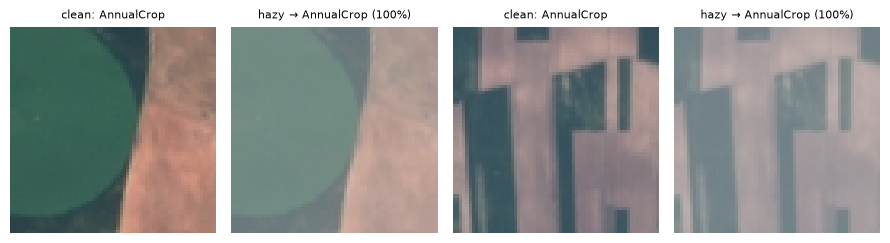

notebook runtime so far: 3.5 min


In [26]:
hazy_x = (test_x.float() * 0.6 + 0.4 * 200).round().clamp(0, 255).to(torch.uint8)
clean_probs = torch.from_numpy(test_probs)
hazy_probs = classifier.predict_proba(hazy_x)


def signals(probs, labels):
    top1 = probs.max(1).values
    distribution = torch.bincount(probs.argmax(1), minlength=len(cfg.CLASSES)).float() / len(probs)
    return {"mean confidence": top1.mean().item(), "needs review": (top1 < review_threshold).float().mean().item(),
            "accuracy (needs labels)": (probs.argmax(1) == labels).float().mean().item()}, distribution


clean_signals, clean_dist = signals(clean_probs, test_y)
hazy_signals, hazy_dist = signals(hazy_probs, test_y)
print(pd.DataFrame({"clean test tiles": clean_signals, "hazy copy": hazy_signals}).round(4).to_string())
shift = 0.5 * (clean_dist - hazy_dist).abs().sum().item()
print(f"predicted-class distribution changed by {shift:.1%} (total variation distance)")
print("→ " + ("the label-free signals (confidence, review share, class mix) move together with the accuracy drop: they are useful early warnings"
             if hazy_signals["needs review"] > clean_signals["needs review"] and hazy_signals["accuracy (needs labels)"] < clean_signals["accuracy (needs labels)"]
             else "the label-free signals did not react as expected: monitoring must rely on labelled samples"))

fig, axes = plt.subplots(1, 4, figsize=(9, 2.6))
for column, i in enumerate([0, 1]):
    show_tile(axes[2 * column], test_x[i], f"clean: {cfg.CLASSES[test_y[i]]}")
    show_tile(axes[2 * column + 1], hazy_x[i], f"hazy → {cfg.CLASSES[hazy_probs[i].argmax()]} ({hazy_probs[i].max():.0%})")
plt.tight_layout()
plt.show()
print(f"notebook runtime so far: {(time.perf_counter() - NOTEBOOK_START) / 60:.1f} min")

**Stretch goals** (good commits for your GitHub version):
1. Train at 128 or 224 px and add the latency cost to the comparison table: is the accuracy gain worth it?
2. Add a **haze/brightness augmentation** and re-run the monitoring cell: does robustness improve without hurting clean accuracy?
3. Export to ONNX and serve with ONNX Runtime; compare image size and latency with the PyTorch image.
4. Add a `POST /predict/batch` endpoint that accepts several files and runs one batched forward pass.
5. Use the multispectral EuroSAT release (13 bands) with [TorchGeo](https://github.com/torchgeo/torchgeo) and compare.

## 🗣️ Interview Walkthrough

The pitch below is generated from the saved metadata and measurements, so every number is real. Practise saying it in about **2 minutes**.

In [27]:
tm = metadata["test_metrics"]
passed = int(criteria["met"].sum())
calibration_note = ("was already close to calibrated" if abs(metadata["temperature"] - 1) < 0.15
                    else f"was {'over' if metadata['temperature'] > 1 else 'under'}-confident, and scaling corrected it")
pitch = f"""
PROBLEM (20 s)
  A monitoring team labels satellite tiles by hand. I built a land-use classifier on EuroSAT: 27,000 Sentinel-2 tiles,
  10 classes, that auto-labels confident tiles and routes uncertain ones to analysts. I set five success criteria up front:
  macro-F1, per-class recall, calibration, CPU latency, and training time.

APPROACH (40 s)
  Stratified 70/15/15 split saved with hashes, and I noted the neighbouring-tile leakage risk of random splits.
  A from-scratch CNN baseline reached {baseline_val_acc:.1%} validation accuracy. ResNet-18 transfer learning, with upsampling and
  normalization inside the model, GPU-side flips/rotations, a one-cycle schedule, lower LR for pretrained layers, and early
  stopping, reached {transfer_val_acc:.1%} in {result.seconds / 60:.1f} minutes on a laptop GPU. I checked confidence with temperature
  scaling on validation (T = {metadata['temperature']:.2f}): the model {calibration_note}. The review threshold of {metadata['review_threshold']:.2f}
  is the lowest at which auto-accepted validation predictions were at least 99% accurate.

RESULT (30 s)
  On the untouched test set, scored with the exported model on CPU: accuracy {tm['accuracy']['estimate']:.1%}
  (95% CI {tm['accuracy']['ci_low']:.1%}–{tm['accuracy']['ci_high']:.1%}), macro-F1 {tm['macro_f1']['estimate']:.3f}, weakest class {per_class['recall'].idxmin()}
  at {per_class['recall'].min():.1%} recall, calibrated ECE {tm['ece_calibrated']:.3f}. {review['coverage']:.0%} of tiles are auto-accepted at
  {review['accuracy_accepted']:.1%} accuracy. {passed} of 5 success criteria met. Error analysis with Grad-CAM showed the main
  confusions: {', '.join(f"{r.true}→{r.predicted}" for r in top_confusions(test_y.numpy(), test_pred, cfg.CLASSES, k=2).itertuples())}.

ENGINEERING (20 s)
  torch.export to a .pt2 file (no model code needed to serve), p95 CPU latency ≈ {cpu_p95_total:.0f} ms including preprocessing;
  a FastAPI upload service with type/size/pixel validation and calibrated top-k plus needs_review; {n_tests_passed} pytest tests
  including a quality gate on a fixed test subset; a CPU-only non-root Docker image; CI that runs fast tests on every push.

NEXT (10 s)
  Region-based splits for a new-country estimate, confidence-based drift monitoring, and robustness to haze.
"""
print(pitch)
print(f"({len(pitch.split())} words ≈ {len(pitch.split()) / 150:.1f} minutes at 150 words per minute)")


PROBLEM (20 s)
  A monitoring team labels satellite tiles by hand. I built a land-use classifier on EuroSAT: 27,000 Sentinel-2 tiles,
  10 classes, that auto-labels confident tiles and routes uncertain ones to analysts. I set five success criteria up front:
  macro-F1, per-class recall, calibration, CPU latency, and training time.

APPROACH (40 s)
  Stratified 70/15/15 split saved with hashes, and I noted the neighbouring-tile leakage risk of random splits.
  A from-scratch CNN baseline reached 91.0% validation accuracy. ResNet-18 transfer learning, with upsampling and
  normalization inside the model, GPU-side flips/rotations, a one-cycle schedule, lower LR for pretrained layers, and early
  stopping, reached 98.0% in 1.4 minutes on a laptop GPU. I checked confidence with temperature
  scaling on validation (T = 1.08): the model was already close to calibrated. The review threshold of 0.75
  is the lowest at which auto-accepted validation predictions were at least 99% accurate.

RESU

**Likely follow-up questions** (answer each in under a minute):

1. *"Why ResNet-18 and not a ViT or EfficientNet?"* — small, fast on CPU, strong ImageNet features, easy to export; with a latency budget and 19k training tiles it's a sensible first choice. I'd compare an EfficientNet/ConvNeXt-Tiny next with the same splits and latency table.
2. *"How do you know the test number isn't optimistic?"* — test touched once after freezing everything; CIs reported; but random splits share locations, so a region split would be the stricter estimate.
3. *"Why is the review threshold chosen on validation?"* — choosing it on test would tune on test data; the test set then honestly reports coverage and accuracy under that rule.
4. *"What happens if someone uploads a 20,000×20,000 PNG?"* — rejected from the header before decoding (pixel limit), and uploads over 5 MB are rejected before decoding at all.
5. *"How would you scale to millions of tiles per day?"* — offline batch inference on GPUs with large batches (or CPU fleets with the exported model), writing results to storage; the API stays for interactive use.
6. *"The exported model disagrees with PyTorch — what happened?"* — usually the model wasn't in `eval()` mode at export (BatchNorm/Dropout), or preprocessing differs; we test agreement explicitly.

## 🎤 Interview Q&A

Try answering **out loud** before opening each answer.

### 🧠 Concepts

**Q1. Why does transfer learning from ImageNet help on satellite images, and how would you decide between freezing and fine-tuning?**

<details><summary>Show answer</summary>

- **30-second answer:** Early and middle layers learn generic features (edges, textures, shapes) that transfer across image domains, so the model starts far better than random and needs less data and time. Freeze the backbone when data is tiny or very similar to ImageNet; fine-tune (with a smaller learning rate for pretrained layers) when you have thousands of images or the domain differs, like overhead imagery.
- **Go deeper:** Discriminative learning rates or gradual unfreezing protect pretrained features early in training. BatchNorm statistics also adapt when fine-tuning; with tiny batches consider freezing BN. Compare head-only vs full fine-tuning on the same validation split — here the from-scratch baseline quantifies the gain.
- **❌ Common wrong answer:** "Pretrained weights only help if the new images look like ImageNet photos."

</details>

**Q2. What is temperature scaling, and why doesn't it change accuracy?**

<details><summary>Show answer</summary>

- **30-second answer:** It divides all logits by one learned scalar T before softmax, fitted by minimizing negative log-likelihood on validation data. Dividing by a positive constant preserves the order of logits, so the argmax (and accuracy) is unchanged, but probabilities become better calibrated.
- **Go deeper:** Guo et al. (2017) showed modern deep nets are often over-confident and that this single parameter fixes much of it. Measure with ECE and reliability diagrams; alternatives are vector/matrix scaling and isotonic regression. Calibration can degrade under distribution shift, so re-check it in production samples.
- **❌ Common wrong answer:** "Use softmax outputs as probabilities — softmax already makes them calibrated."

</details>

**Q3. Explain Grad-CAM and its limitations.**

<details><summary>Show answer</summary>

- **30-second answer:** Grad-CAM takes a convolutional layer's activation maps, weights each channel by the average gradient of the class score with respect to it, sums them, and applies ReLU. The result is a coarse heatmap of where evidence for that class came from, useful for spotting shortcuts on correct and wrong predictions.
- **Go deeper:** Resolution equals that layer's grid (here 6×6 on `layer3`, 3×3 on `layer4` at 96 px), so it can't show fine detail. It shows *where*, not *why*, and can look plausible even for poorly trained models (sanity checks: randomize weights and confirm the map changes). Alternatives: Integrated Gradients, occlusion maps, SHAP for images.
- **❌ Common wrong answer:** "Grad-CAM proves the model understands the object."

</details>

**Q4. `torch.export`, TorchScript, and ONNX: what are they and which would you use?**

<details><summary>Show answer</summary>

- **30-second answer:** `torch.export` captures a full graph of standard ATen operators with dynamic-shape specs into an ExportedProgram (`.pt2`), the current PyTorch path for deployment (AOTInductor, ExecuTorch, and the ONNX exporter build on it). TorchScript is the older scripting/tracing approach and is deprecated. ONNX is a cross-framework format for runtimes like ONNX Runtime or TensorRT.
- **Go deeper:** `torch.export` fails loudly on untraceable Python control flow instead of silently specializing, which is safer. Always export in `eval()` mode, mark dynamic dimensions (`torch.export.Dim`), and test numerical parity against eager on several batch sizes. Pin the PyTorch version between export and load.
- **❌ Common wrong answer:** "Use `torch.jit.trace` — it's the standard way to deploy PyTorch."

</details>

**Q5. Why put normalization and resizing inside the model?**

<details><summary>Show answer</summary>

- **30-second answer:** It removes a second copy of preprocessing from the serving code, which is the most common source of training/serving skew (wrong mean/std, BGR vs RGB, different resize). The exported artifact then defines its own input contract: `[0, 1]` RGB tiles.
- **Go deeper:** Keep decoding (JPEG → pixels) in one shared function too, and test it: our API test asserts that served predictions equal offline predictions. Trade-off: preprocessing inside the graph runs on the model's device and can't be skipped by clients that already have tensors.
- **❌ Common wrong answer:** "Preprocessing belongs in the client, so the model stays pure."

</details>

### 🏗️ Design

**Q6. Design a safe image-upload inference endpoint.**

<details><summary>Show answer</summary>

- **30-second answer:** Validate cheap things first: content type (415), byte size limit (413), then decode with a pixel-count limit from the header (400), and parameter ranges (422). Load the model once at startup, warm it up, expose liveness and readiness, run CPU-bound inference in a thread pool (or a separate worker), and return versioned, calibrated outputs.
- **Go deeper:** Verify that the decoded format matches the declared type, strip EXIF orientation issues if relevant, rate-limit, set request timeouts, log input metadata (not images, unless allowed), and consider dynamic batching on GPU. Limit threads per replica (`OMP_NUM_THREADS`) and scale horizontally.
- **❌ Common wrong answer:** "Accept any file and let PIL figure it out."

</details>

**Q7. How would you let humans handle the cases the model is unsure about?**

<details><summary>Show answer</summary>

- **30-second answer:** Calibrate probabilities on validation data, build a coverage-vs-accuracy table over confidence thresholds, and pick the threshold that meets the required accuracy for auto-accepted items. Everything below goes to a review queue; the reviewed labels become new training data.
- **Go deeper:** The threshold is a business trade-off between labelling cost and error cost. Monitor the review rate: a sudden increase signals drift. Reviewed low-confidence items are also ideal for active learning. Confidence isn't perfect: confident mistakes still exist, so audit a random sample of auto-accepted items too.
- **❌ Common wrong answer:** "Flag anything below 50% probability."

</details>

**Q8. Your random split gives 98% accuracy. Why might a customer in a new region see much less?**

<details><summary>Show answer</summary>

- **30-second answer:** Neighbouring tiles from the same scenes land in both train and test, so the test set measures familiar places, not new ones. New regions differ in crops, building styles, season, and sensor conditions (domain shift). Split by region or scene to estimate that honestly.
- **Go deeper:** This is group leakage, the same as putting one patient's scans in both splits. Use `GroupKFold`/group-aware splits, report per-region metrics, and collect a small labelled sample from the new region to measure and fine-tune.
- **❌ Common wrong answer:** "98% on a held-out test set means it generalizes."

</details>

### 🐛 Debugging Scenarios

**Q9. Validation accuracy is 97%, but predictions on images uploaded through the API are nearly random. What do you check?**

<details><summary>Show answer</summary>

- **30-second answer:** Training/serving skew in preprocessing: channel order (RGB vs BGR from OpenCV), value range (0–255 vs 0–1), normalization applied twice or not at all, resize method and size, grayscale or RGBA inputs, and whether the model is in eval mode. Compare the exact tensor fed to the model offline and in the API for the same file.
- **Go deeper:** Prevent it structurally: one shared decode function, normalization inside the exported model, and a test asserting API output equals offline prediction for real files. Also confirm the served model version is the one you evaluated.
- **❌ Common wrong answer:** "The model overfit; retrain with more augmentation."

</details>

**Q10. The exported model's outputs differ from the eager model by a lot. What went wrong?**

<details><summary>Show answer</summary>

- **30-second answer:** Most often the model was exported in training mode, so BatchNorm used batch statistics and Dropout was active. Other causes: the example input had a different dtype/range, dynamic shapes were specialized to the example batch size, or different library versions at export and load.
- **Go deeper:** Export an `eval()` copy on CPU, check parity on several batch sizes (as Step 7 does), keep export and serving PyTorch versions identical (the lock file pins it), and store the PyTorch version in the metadata. Small differences around 1e-6 are normal floating-point noise between devices.
- **❌ Common wrong answer:** "Exported models are always a bit less accurate, that's expected."

</details>

**Q11. The CPU container is slow and uses 16 threads at 1,600% CPU under light load. Why?**

<details><summary>Show answer</summary>

- **30-second answer:** PyTorch's intra-op thread pool defaults to the number of cores the process can see, and several replicas (or uvicorn workers) on one host each start that many threads, so they fight over cores. Set `OMP_NUM_THREADS` / `torch.set_num_threads` per replica and scale by replicas instead.
- **Go deeper:** Measure p95 at the real concurrency with a load test; tune threads × replicas; use CPU requests/limits in Kubernetes; consider batching requests. Also confirm you installed CPU wheels, not CUDA wheels, to keep the image small.
- **❌ Common wrong answer:** "Add more uvicorn workers."

</details>

## 📚 Resources

### 📖 Official Docs
- [PyTorch — torch.export](https://docs.pytorch.org/docs/2.14/user_guide/torch_compiler/export.html) — ExportedProgram, dynamic shapes, saving and loading
- [torchvision — Models and pre-trained weights](https://docs.pytorch.org/vision/stable/models.html) — weights enums and their preprocessing
- [FastAPI — Request Files](https://fastapi.tiangolo.com/tutorial/request-files/) — `UploadFile` and multipart uploads
- [PyTorch — Get Started (CPU wheels)](https://pytorch.org/get-started/locally/) — choosing CPU vs CUDA builds

### 🎥 Videos
- [3Blue1Brown — But what is a convolution?](https://www.youtube.com/watch?v=KuXjwB4LzSA) (~23 min) — visual intuition for the operation every layer here performs
- [Stanford CS231n — Lecture 5: Convolutional Neural Networks](https://www.youtube.com/watch?v=bNb2fEVKeEo) (~1 h) — classic lecture on CNN architecture and why deep features transfer
- [freeCodeCamp (Daniel Bourke) — PyTorch for Deep Learning & Machine Learning](https://www.youtube.com/watch?v=V_xro1bcAuA) (~25 h, use chapters) — the transfer learning and model deployment chapters mirror this project

### 📄 Papers
- [Helber et al. (2019) — EuroSAT: A Novel Dataset and Deep Learning Benchmark for Land Use and Land Cover Classification](https://arxiv.org/abs/1709.00029) — the dataset
- [He et al. (2015) — Deep Residual Learning for Image Recognition](https://arxiv.org/abs/1512.03385) — ResNet
- [Guo et al. (2017) — On Calibration of Modern Neural Networks](https://arxiv.org/abs/1706.04599) — over-confidence and temperature scaling
- [Selvaraju et al. (2017) — Grad-CAM](https://arxiv.org/abs/1610.02391) — the heatmap method used in error analysis

### 📘 Books & Courses
- [Andrej Karpathy — A Recipe for Training Neural Networks](http://karpathy.github.io/2019/04/25/recipe/) — the debugging-first training workflow this project follows
- [Dive into Deep Learning — Fine-Tuning](https://d2l.ai/chapter_computer-vision/fine-tuning.html) — free book chapter on transfer learning with code

### 🏋️ Practice
- [EuroSAT on GitHub](https://github.com/phelber/EuroSAT) — includes the 13-band multispectral version for a harder follow-up
- [TorchGeo](https://github.com/torchgeo/torchgeo) — geospatial datasets, samplers for region-based splits, and pretrained satellite models

## ➡️ What's Next

**[03 · LLM RAG Assistant Project](03_LLM_RAG_Assistant_Project.ipynb)** — the same production discipline (evaluation sets, one honest test, a tested API, containers, monitoring) applied to a retrieval-augmented LLM assistant, where "accuracy" becomes groundedness and answer quality.